# Immunization & SIR simulations on artificial networks


### Simulation workflow

Generally, the simulations work as follows:
- *Network generation*: 
    - generate $n_{nw\_reps}$ network instances for each modularity setting (corresponding to different numbers of rewiring steps) using the method described by Salathé-Jones (2010). On each instance, run the immunization and SIR simulation steps.
- *Immunization*:
    - set desired immunization coverage(s), and run each of the implemented algorithms (Random, degree-based, ACQ, CBF, BHD, BNI-LI) on the given network instance, for each obtaining a set of immunized nodes corresponding to the desired coverage
- *SIR simulation*
    - specify settings of transmission rate $\beta$, recovery rate $\gamma$ to explore
    - perform SIR simulations with the EoN module, setting sets of immunized nodes obtained from the algorithms in the previous step as initial recovered nodes (before the first infections)
    - per combination of $\beta$, $\gamma$, set of immunized nodes obtained from a single combination of algorithm and coverage setting, perform $n_{sir\_reps}=100$ repetitions of the SIR simulation.


In [25]:
# library imports
import numpy as np   
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import immunization_funcs as imf # this is where the immunization strategies are implemented, see immunization_funcs.py
import sim_funcs as sf # this contains the simulation sweeps

### Running simulations

The simulation has been running for: ~10000 min

```python
# parameter ranges
rewire_step_list = np.arange(-1750, 1751, 250) # 15
coverage_list = np.array([0.01, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.25]) # all values
beta_list = np.array([0.16]) # 1 values
gamma_list = np.array([0.1]) # 1 valuest
n_network_reps = 1
n_immunize_reps = 100   
n_sir_reps = 100

# warning, this sim takes AGES to run
sf.run_gen_sweep(rewire_step_list, coverage_list, beta_list, gamma_list,
                 n_network_reps=n_network_reps,
                 n_sir_reps=n_sir_reps,
                 n_immunize_reps=n_immunize_reps,
                 output_path='results/beta0p16_gamma0p1.parquet', 
                 resume=True)
```

## Analysing & plotting simulation results

Let's start by setting up some constants and functions:

In [26]:
# the result metrics we collected
METRICS = ["final_attack_ratio", "peak_prevalence", "duration"]
METRIC_LABELS = {
    "final_attack_ratio": "Final attack ratio",
    "peak_prevalence": "Peak prevalence",
    "duration": "Duration",
}
METRIC_TITLES = ["Final Attack Ratio", "Peak Prevalence", "Epidemic Duration"]

# Columns that encode ids of simulation reps- we average and then drop them
DROP_COLS = ["network_rep", "sir_rep", "imm_rep"]

# This well be for the columns listing the 'best' algorithms based on specific result metrics
# (used throughout compute_best_algorithms and plot_algo_heatmaps)
METRIC_MAP = {
    "alg_final":    "final_attack_ratio",
    "alg_peak":     "peak_prevalence",
    "alg_duration": "duration",
}

METRIC_VAR_MAP = {
    "final_attack_ratio": "R",
    "peak_prevalence": "P",
    "duration": "T",
}

In [27]:
def avg_over_reps(
    df: pd.DataFrame,
    group_cols: list[str],
    drop_cols: list[str] = DROP_COLS,
) -> pd.DataFrame:
    """Average all numeric columns over SIR / immunization/ network repetitions.

    Parameters
    ----------
    df         : raw simulation results
    group_cols : columns that uniquely identify the simulation parameter combination
                (here, should be rewire_steps, coverage, algorithm, beta, gamma)
    drop_cols  : repetetition index columns to discard after averaging

    Returns
    -------
    DataFrame with one row per condition, containing per-metric averages.
    """
    return (
        df.groupby(group_cols, as_index=False, observed=True)
          .mean(numeric_only=True)
          .drop(columns=[c for c in drop_cols if c in df.columns])
    )


def compute_best_algorithms(
    df_avg: pd.DataFrame,
    scenario_levels: list[str],
    metric_map: dict[str, str] = METRIC_MAP,
) -> pd.DataFrame:
    """For each parameter combo, find the algorithm with the best (lowest) value per result metric.

    Parameters
    ----------
    df_avg          : DataFrame averaged over replicates; must contain an
                      'algorithm' column plus all metric columns
    scenario_levels : columns that define a parameter combination, EXCLUDING 'algorithm'
    metric_map      : {output_column: result_metric_column}

    Returns
    -------
    DataFrame with parameter combos + any extra numeric columns (e.g. modularity)
    + one 'alg_*' column per metric holding the best algorithm's name.

    """
    grouped = df_avg.groupby(scenario_levels)

    # Carry forward the mean of numeric columns that are neither combo
    # nor metrics (e.g. modularity when grouping by rewire_steps).
    metric_vals  = set(metric_map.values())
    extra_numeric = [
        c for c in df_avg.select_dtypes("number").columns
        if c not in scenario_levels and c not in metric_vals
    ]

    if extra_numeric:
        best = grouped[extra_numeric].mean().reset_index()
    else:
        best = grouped.size().reset_index(name="_n").drop(columns="_n")

    for out_col, metric in metric_map.items():
        best_idx      = grouped[metric].idxmin()          # integer row labels
        best[out_col] = df_avg.loc[best_idx, "algorithm"].to_numpy()

    return best

##########################################
# and the visualisation funcs
##########################################
def make_color_encoding(algorithms: list[str], palette = None):
    """Make categorical colour encoding for a list of algorithms to be able to plot them
    as a heatmap with seaborn.

    Parameters
    ----------
    algorithms     : list of algorithm names for heatmap
    Returns
    -------
    algo_to_code   : {algorithm_name: integer_code}
    palette        : list of RGB tuples
    cmap           : ListedColormap
    norm           : BoundaryNorm
    legend_handles : list of Patch objects suitable for ax.
    (handles=...)
    """
    algorithms   = sorted(set(algorithms))
    n            = len(algorithms)
    algo_to_code = {alg: i for i, alg in enumerate(algorithms)}
    if palette is None:
        palette      = sns.color_palette("tab10", n_colors=n)
    cmap         = mcolors.ListedColormap(palette)
    norm         = mcolors.BoundaryNorm(np.arange(-0.5, n + 0.5, 1), ncolors=n)
    legend_handles = [
        mpatches.Patch(facecolor=palette[i], label=algorithms[i])
        for i in range(n)
    ]
    return algo_to_code, palette, cmap, norm, legend_handles


def _pivot_column(
    df: pd.DataFrame,
    col: str,
    algo_to_code: dict,
    row: str = "coverage",
    col_: str = "modularity",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Pivot a best-algorithm column into numeric-code and label DataFrames,
    to bring it in the format needed for the seaborn heatmap
    """
    df = df.copy()
    df[col + "_code"] = df[col].map(algo_to_code)
    pivot_code  = df.pivot(index=row, columns=col_, values=col + "_code").iloc[::-1]
    pivot_label = df.pivot(index=row, columns=col_, values=col).iloc[::-1]
    return pivot_code, pivot_label


def plot_algo_heatmaps(
    best_filtered: pd.DataFrame,
    algo_to_code: dict,
    cmap,
    norm,
    legend_handles: list,
    metric_map: dict[str, str] = METRIC_MAP,
    col_titles: list[str] = METRIC_TITLES,
    suptitle: str = "Best-performing algorithm by metric",
    save_path: str | None = None,
    annotate = True,
) -> plt.Figure:
    """Make vertically-stacked figure with the best-algorithm heatmaps for each result metric.

    Parameters
    ----------
    best_filtered  : output of compute_best_algorithms, filtered to a single
                     (beta, gamma) slice; must contain 'coverage' and
                     'modularity' (already rounded) with unique combinations.
    algo_to_code   : from make_color_encoding
    cmap / norm    : from make_color_encoding
    legend_handles : from make_color_encoding
    metric_map     : same mapping passed to compute_best_algorithms
    col_titles     : human-readable panel titles (same order as metric_map keys)
    save_path      : if given, save figure to this path at 300 dpi
    annotate       : Whether to annotate the heatmap panels.
    """
    col_names = list(metric_map.keys())
    n_panels  = len(col_names)
    fig, axes = plt.subplots(n_panels, 1, figsize=(8.5, 4.5 * n_panels))
    if n_panels == 1:
        axes = [axes]

    for ax, col, title in zip(axes, col_names, col_titles):
        pivot_code, pivot_label = _pivot_column(best_filtered, col, algo_to_code)
        sns.heatmap(
            pivot_code,
            ax=ax,
            cmap=cmap,
            norm=norm,
            linewidths=0.5,
            linecolor="black",
            annot=pivot_label if annotate else None,
            fmt="",
            annot_kws={"size": 10, "color": "black"},
            cbar=False,
        )
        ax.set_title(f"Best algorithm — {title}", fontsize=12, pad=10)
        ax.set_xlabel("Modularity", fontsize=12)
        ax.set_ylabel("Coverage",   fontsize=12)
        ax.legend(
            handles=legend_handles,
            title="Algorithm",
            loc="upper right",
            bbox_to_anchor=(1.4, 1),
            frameon=True,
            fontsize=12,
            markerscale=2
        )

    plt.suptitle(suptitle, fontsize=14, y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig


def plot_metrics(
    data: pd.DataFrame,
    x_col: str,
    slice_col: str,
    slice_val: float,
    *,
    x_label: str,
    slice_label: str,
    metrics: list[str] = METRICS,
    metric_labels: dict = METRIC_LABELS,
    save_path: str | None = None,
) -> plt.Figure:
    """Draw a figure with one panel per result metric using seaborn lineplot.

    Parameters
    ----------
    data         : pre-filtered DataFrame (restricted to a single slice)
    x_col        : column for the x-axis ('modularity' or 'coverage')
    slice_col    : column used to select the slice (used in suptitle)
    slice_val    : value of that column (used in suptitle)
    x_label      : human-readable x-axis label
    slice_label  : human-readable slice description
    save_path    : if given, save figure to this path at 150 dpi
    """
    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4), sharey=False)
    fig.suptitle(f"{slice_label} = {slice_val:.2f}", fontsize=13, y=1.01)

    for ax, metric in zip(axes, metrics):
        sns.lineplot(
            data=data, x=x_col, y=metric,
            hue="algorithm", marker="o", ax=ax,
        )
        ax.set_xlabel(x_label,               fontsize=11)
        ax.set_ylabel(metric_labels[metric], fontsize=11)
        ax.set_title(metric_labels[metric],  fontsize=11)
        ax.get_legend().remove()
        ax.grid(alpha=0.3)

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title="Algorithm",
        loc="lower center",
        ncol=len(labels),
        bbox_to_anchor=(0.5, -0.12),
        frameon=True,
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return fig

### Algorithm comparison

In [28]:
GROUP_COLS = ["rewire_steps", "modularity", "algorithm", "coverage", "beta", "gamma"] 
SCENARIO_COLS = ["rewire_steps", "modularity", "coverage", "beta", "gamma"]

# Modularity levels (expressed as rewire_steps) for the coverage-sweep curves
REWIRE_LEVELS = [-1000, 1000]

# Coverage levels for the modularity-sweep curves
COVERAGE_LEVELS = [0.01, 0.1]

In [29]:
# Load & combine 
filenames = [
    "results/beta0p08_gamma0p2_pt1.parquet",
    "results/beta0p08_gamma0p2_pt2.parquet",
    "results/beta0p08_gamma0p2_pt3.parquet",
    "results/beta0p08_gamma0p2_pt4.parquet",
    "results/beta0p04_gamma0p2_pt1.parquet",
    "results/beta0p04_gamma0p2_pt2.parquet",
    "results/beta0p04_gamma0p2_pt3.parquet",
    "results/beta0p04_gamma0p2_pt4.parquet",
    "results/beta0p16_gamma0p2_pt1.parquet",
    "results/beta0p16_gamma0p2_pt2.parquet",
    "results/beta0p16_gamma0p2_pt3.parquet",
    "results/beta0p16_gamma0p2_pt4.parquet",
    "results/beta0p08_gamma0p1.parquet",
    "results/beta0p04_gamma0p1.parquet",
    "results/beta0p16_gamma0p1_ptA.parquet",
    "results/beta0p16_gamma0p1_ptB.parquet"
]
dfs = [pd.read_parquet(file) for file in filenames]
df  = pd.concat(dfs, ignore_index=True)
df  = df.query("algorithm not in ['Degree', 'Random']")

In [30]:
# there's a small naming inconsistency in one of the files (beta0p16_gamma0p1_ptA.parquet)
# we need to rename the BNI-LI and BNI-LI-local to be consistent with the other files
df.loc[df['algorithm'] == 'BNI-LI-random-trial', 'algorithm'] = 'BNI-LI'
df.loc[df['algorithm'] == 'BNI-LI-random-trial-local', 'algorithm'] = 'BNI-LI-local'

Heatmap grid: 10 coverage levels × 15 modularity levels


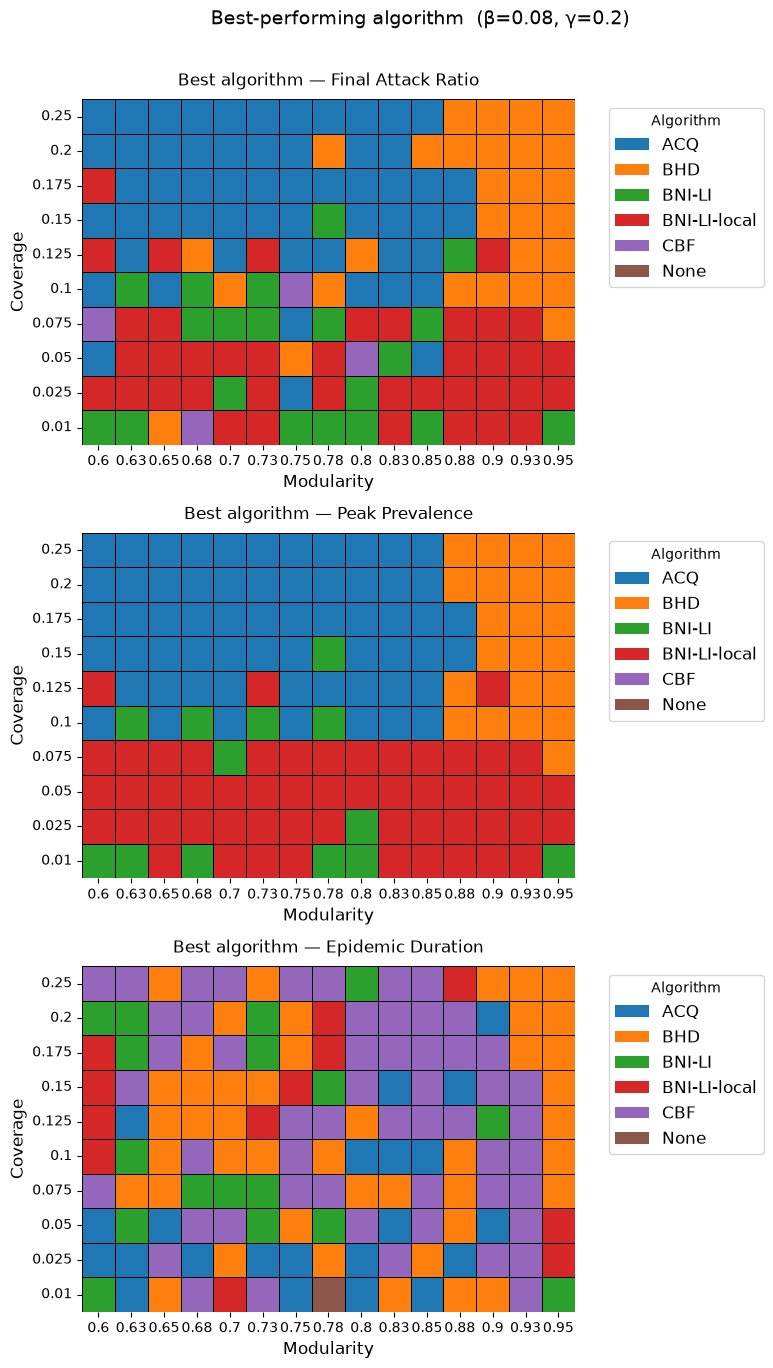

In [31]:
BETA_SLICE = 0.08
GAMMA_SLICE = 0.2
# avg over SIR / immunization / network reps, to get one mean value per metric for each parameter combo
df_avg = avg_over_reps(df, group_cols=GROUP_COLS)

# get best algorithm for each metric
best = compute_best_algorithms(df_avg, SCENARIO_COLS)

# Prepare the heatmap data 
best["modularity"] = best["modularity"].round(2)

# filter y beta and gamma slice
# When two rewire_steps values round to the same modularity, resolve ties by
# majority vote (mode) across the duplicated (coverage, modularity) cells.
alg_cols = list(METRIC_MAP.keys())
best_filtered = (
    best
    .query(f"beta == {BETA_SLICE} and gamma == {GAMMA_SLICE}")
    .groupby(["coverage", "modularity"], as_index=False)[alg_cols]
    .agg(lambda x: x.mode().iat[0])
)

print(f"Heatmap grid: {best_filtered['coverage'].nunique()} coverage levels "
      f"× {best_filtered['modularity'].nunique()} modularity levels")

# Build shared colour encoding and draw the figure
all_algorithms = sorted(
    pd.concat([best_filtered[c] for c in alg_cols]).unique()
)
algo_to_code, palette, cmap, norm, legend_handles = make_color_encoding(all_algorithms)

plot_algo_heatmaps(
    best_filtered,
    algo_to_code=algo_to_code,
    cmap=cmap,
    norm=norm,
    legend_handles=legend_handles,
    suptitle=f"Best-performing algorithm  (β={BETA_SLICE}, γ={GAMMA_SLICE})",
    save_path="figures/algo_heatmaps_beta0p08_gamma0p2.png",
    annotate=False
)
plt.show()

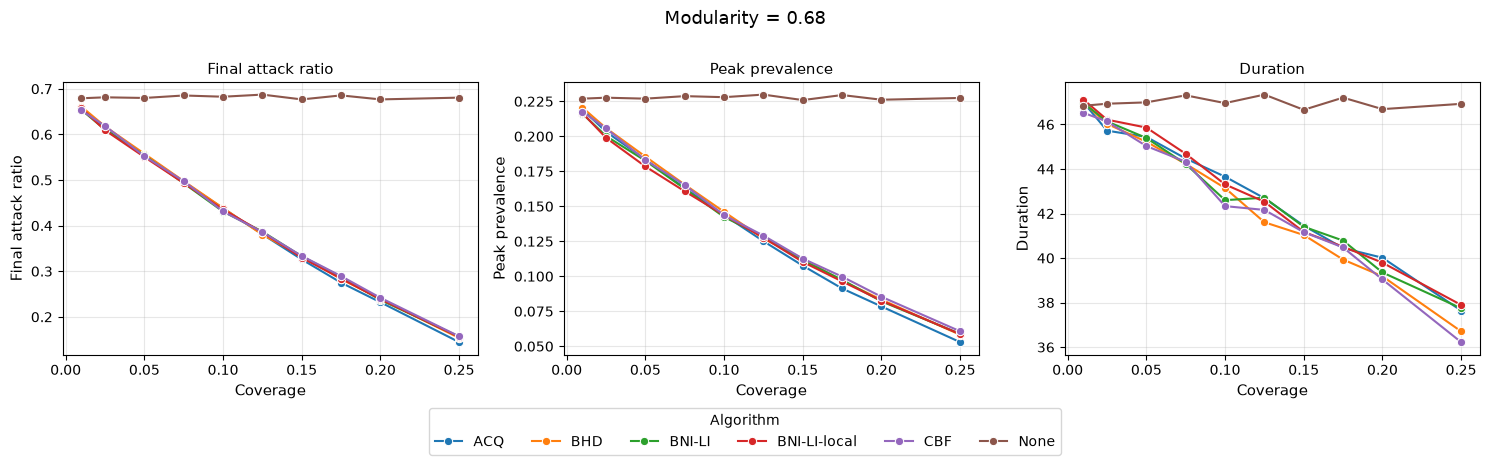

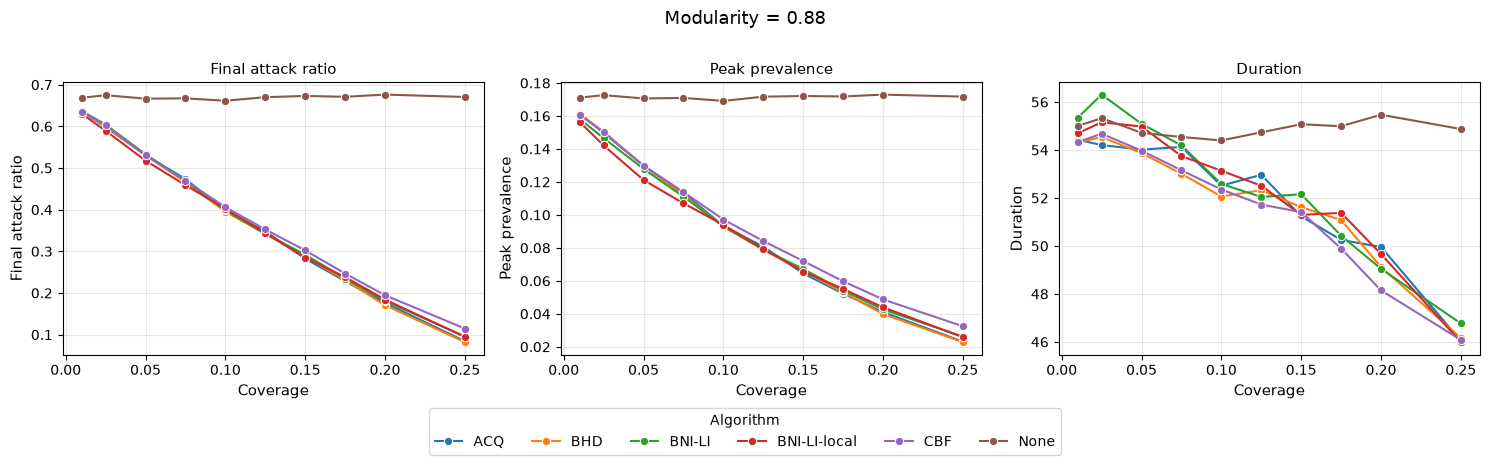

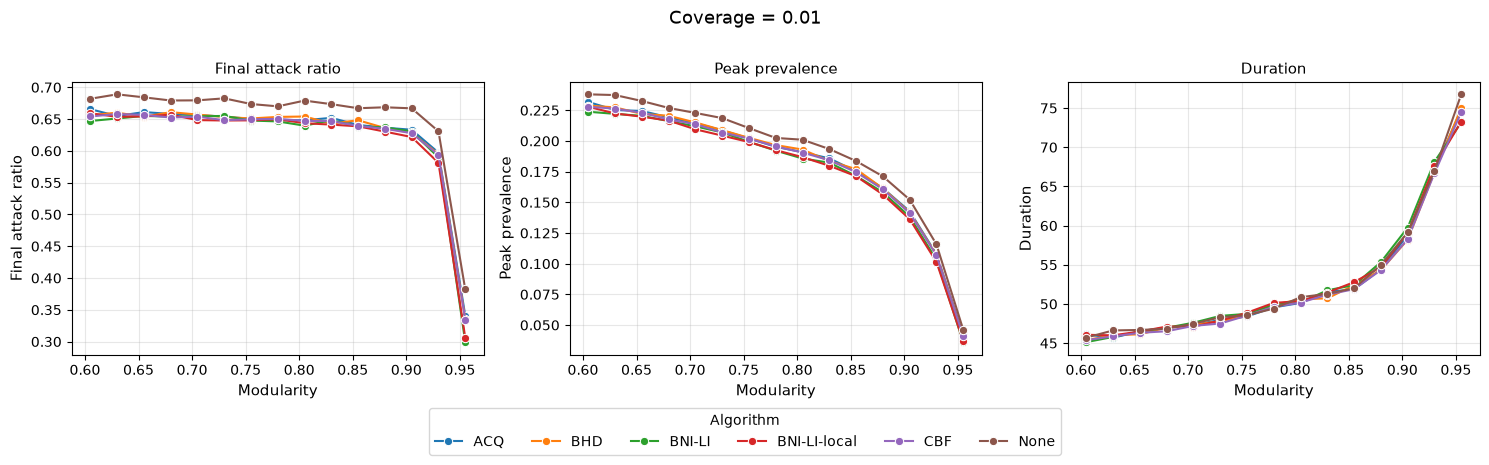

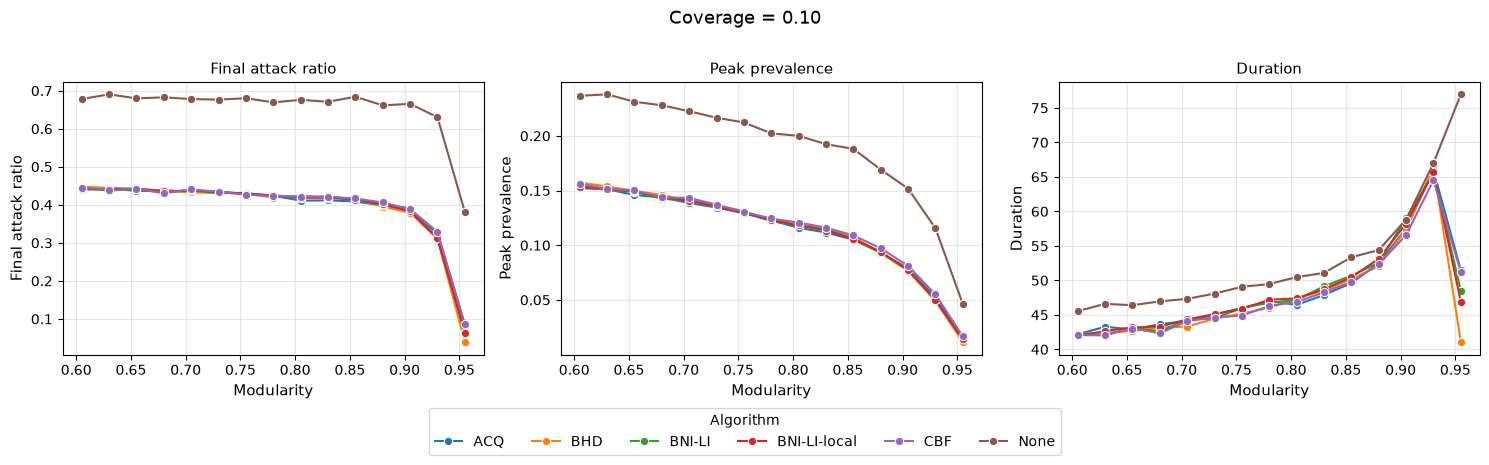

In [32]:
# filter for beta/gamma slice
df_sub = df_avg.query(f"beta == {BETA_SLICE} and gamma == {GAMMA_SLICE}")

# Build a rewire_steps → mean modularity lookup for readable slice labels.
rewire_to_mod = df_sub.groupby("rewire_steps")["modularity"].mean().round(2)

# Metric vs. coverage, for selected modularity (rewire_steps) levels 
for rw in REWIRE_LEVELS:
    subset  = df_sub.query("rewire_steps == @rw")
    mod_val = rewire_to_mod.loc[rw]
    plot_metrics(
        subset,
        x_col="coverage",
        slice_col="modularity",
        slice_val=mod_val,
        x_label="Coverage",
        slice_label="Modularity",
        save_path=f"figures/metric_vs_coverage_mod{mod_val}.png",
    )

# Metric vs. modularity, for selected coverage levels 
for cov in COVERAGE_LEVELS:
    subset = df_sub.query("coverage == @cov")
    plot_metrics(
        subset,
        x_col="modularity",
        slice_col="coverage",
        slice_val=cov,
        x_label="Modularity",
        slice_label="Coverage",
        save_path=f"figures/metric_vs_modularity_cov{cov}.png",
    )

Heatmap grid: 10 coverage levels × 15 modularity levels


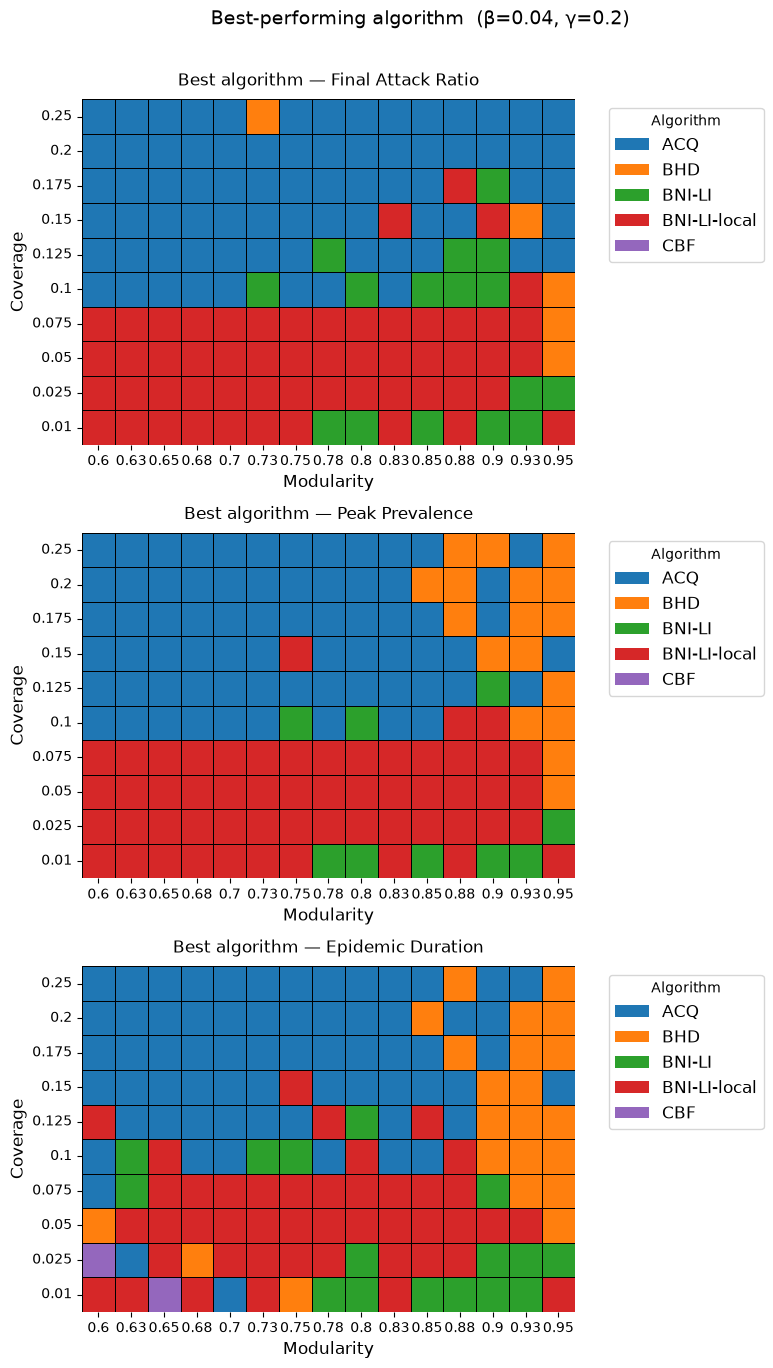

In [33]:
BETA_SLICE = 0.04
GAMMA_SLICE = 0.2

# filter y beta and gamma slice
# When two rewire_steps values round to the same modularity, resolve ties by
# majority vote (mode) across the duplicated (coverage, modularity) cells.
alg_cols = list(METRIC_MAP.keys())
best_filtered = (
    best
    .query(f"beta == {BETA_SLICE} and gamma == {GAMMA_SLICE}")
    .groupby(["coverage", "modularity"], as_index=False)[alg_cols]
    .agg(lambda x: x.mode().iat[0])
)

print(f"Heatmap grid: {best_filtered['coverage'].nunique()} coverage levels "
      f"× {best_filtered['modularity'].nunique()} modularity levels")

# Build shared colour encoding and draw the figure
all_algorithms = sorted(
    pd.concat([best_filtered[c] for c in alg_cols]).unique()
)
algo_to_code, palette, cmap, norm, legend_handles = make_color_encoding(all_algorithms)

plot_algo_heatmaps(
    best_filtered,
    algo_to_code=algo_to_code,
    cmap=cmap,
    norm=norm,
    legend_handles=legend_handles,
    suptitle=f"Best-performing algorithm  (β={BETA_SLICE}, γ={GAMMA_SLICE})",
    save_path="figures/algo_heatmaps_beta0p04_gamma0p2.png",
    annotate=False
)
plt.show()

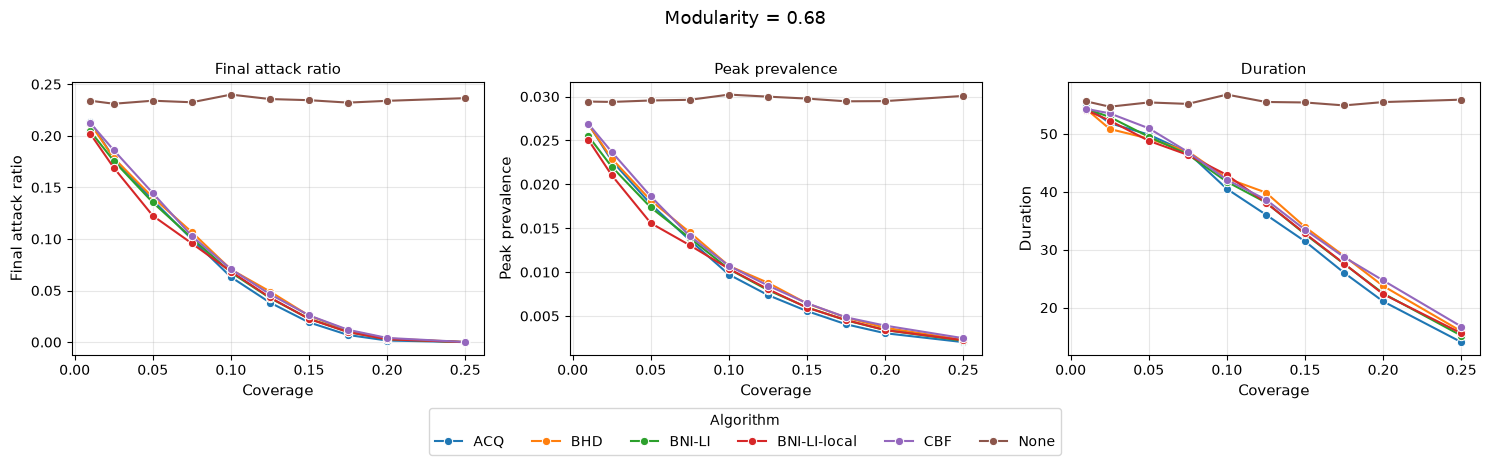

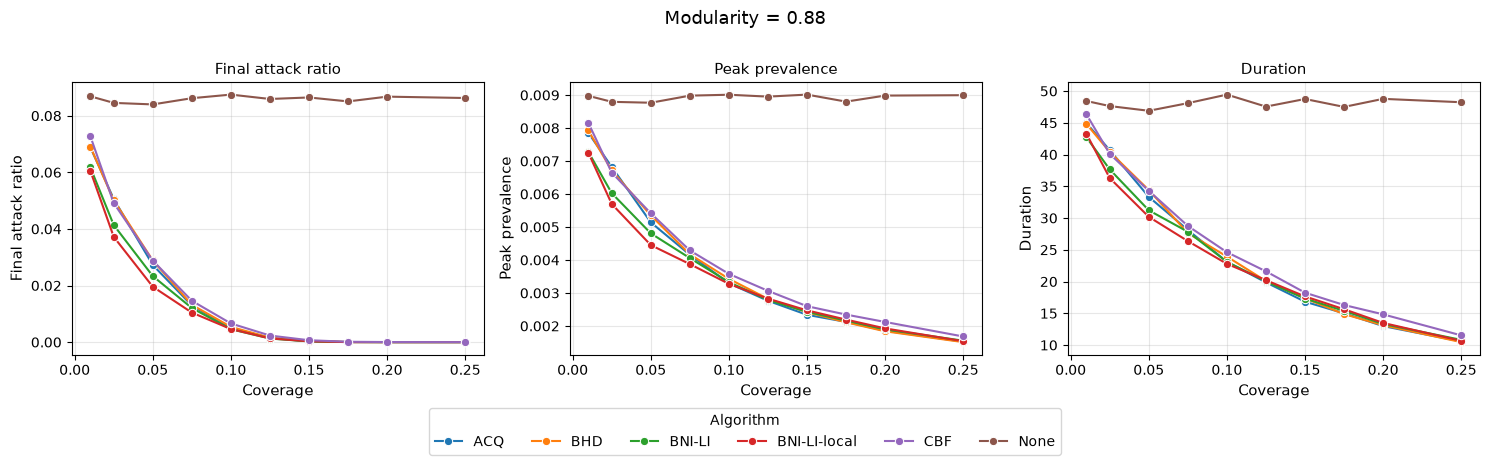

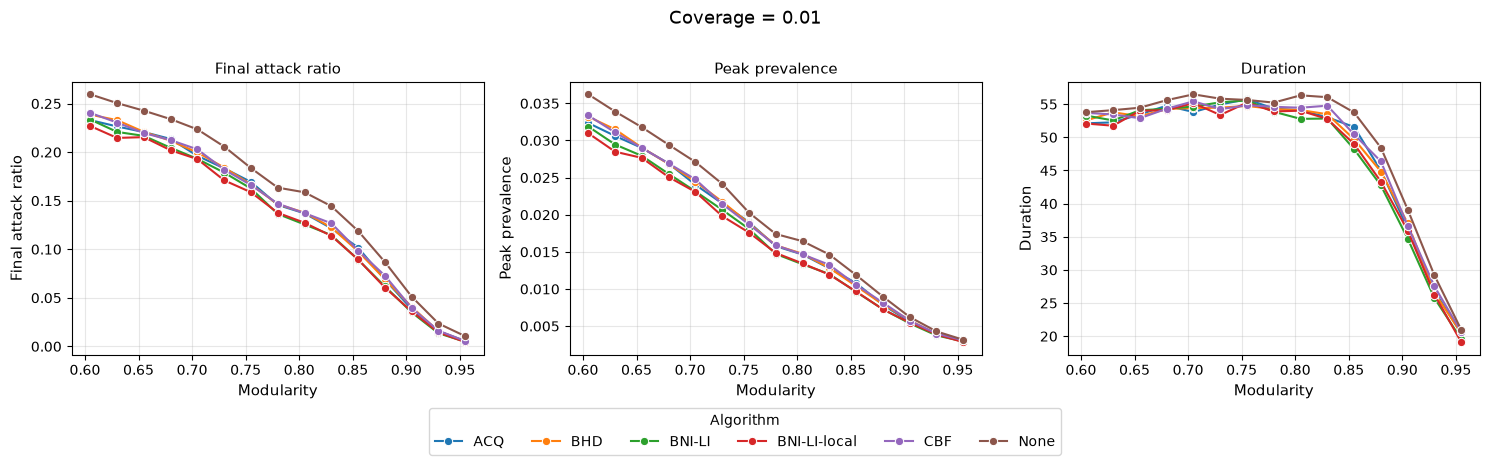

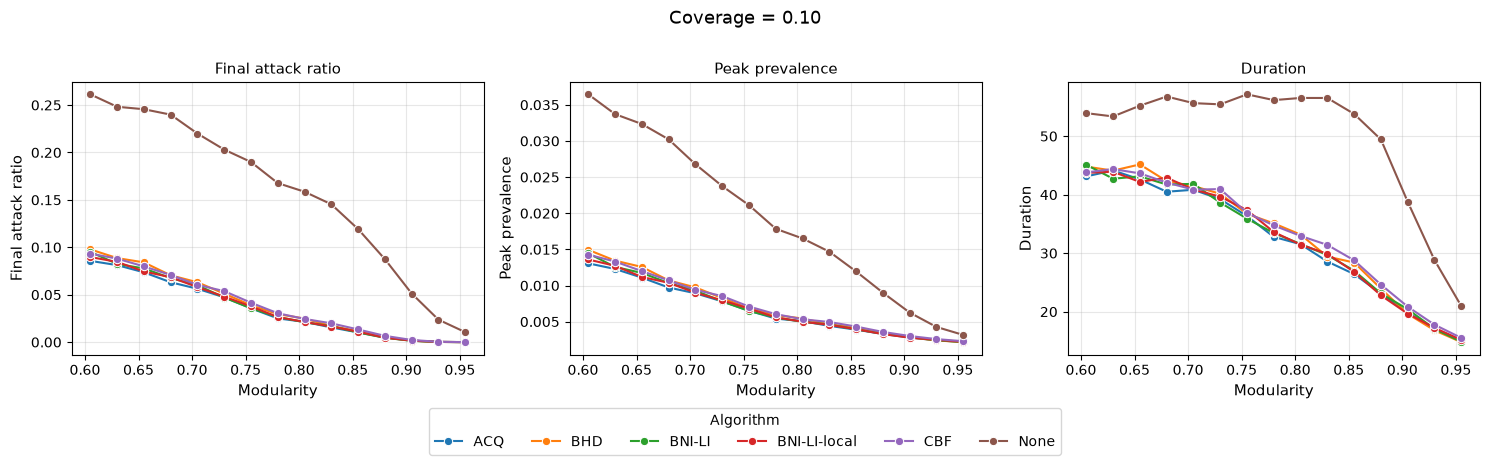

In [34]:
# filter for beta/gamma slice
df_sub = df_avg.query(f"beta == {BETA_SLICE} and gamma == {GAMMA_SLICE}")

# Build a rewire_steps → mean modularity lookup for readable slice labels.
rewire_to_mod = df_sub.groupby("rewire_steps")["modularity"].mean().round(2)

# Metric vs. coverage, for selected modularity (rewire_steps) levels 
for rw in REWIRE_LEVELS:
    subset  = df_sub.query("rewire_steps == @rw")
    mod_val = rewire_to_mod.loc[rw]
    plot_metrics(
        subset,
        x_col="coverage",
        slice_col="modularity",
        slice_val=mod_val,
        x_label="Coverage",
        slice_label="Modularity",
        save_path=f"figures/metric_vs_coverage_mod{mod_val}.png",
    )

# Metric vs. modularity, for selected coverage levels 
for cov in COVERAGE_LEVELS:
    subset = df_sub.query("coverage == @cov")
    plot_metrics(
        subset,
        x_col="modularity",
        slice_col="coverage",
        slice_val=cov,
        x_label="Modularity",
        slice_label="Coverage",
        save_path=f"figures/metric_vs_modularity_cov{cov}.png",
    )

Heatmap grid: 10 coverage levels × 15 modularity levels


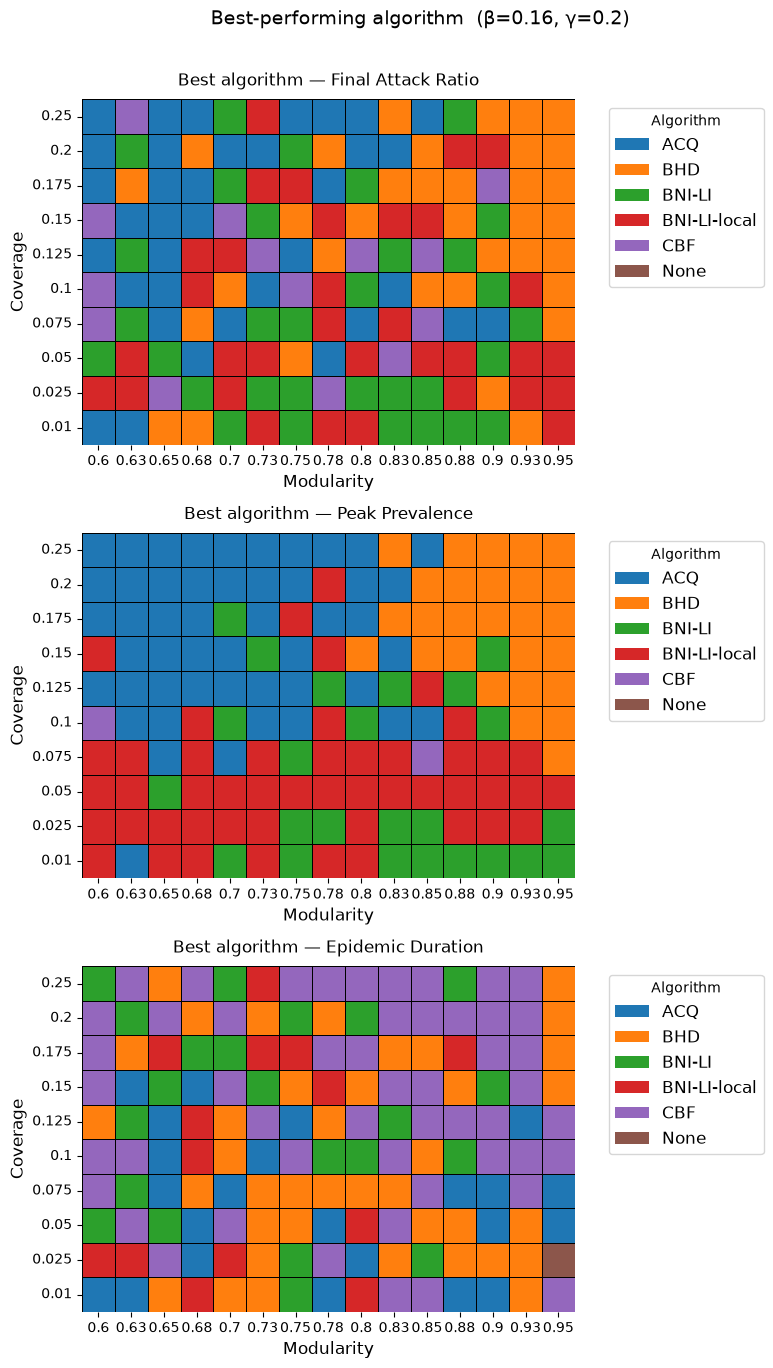

In [35]:
BETA_SLICE = 0.16
GAMMA_SLICE = 0.2

# filter y beta and gamma slice
# When two rewire_steps values round to the same modularity, resolve ties by
# majority vote (mode) across the duplicated (coverage, modularity) cells.
alg_cols = list(METRIC_MAP.keys())
best_filtered = (
    best
    .query(f"beta == {BETA_SLICE} and gamma == {GAMMA_SLICE}")
    .groupby(["coverage", "modularity"], as_index=False)[alg_cols]
    .agg(lambda x: x.mode().iat[0])
)

print(f"Heatmap grid: {best_filtered['coverage'].nunique()} coverage levels "
      f"× {best_filtered['modularity'].nunique()} modularity levels")

# Build shared colour encoding and draw the figure
all_algorithms = sorted(
    pd.concat([best_filtered[c] for c in alg_cols]).unique()
)
algo_to_code, palette, cmap, norm, legend_handles = make_color_encoding(all_algorithms)

plot_algo_heatmaps(
    best_filtered,
    algo_to_code=algo_to_code,
    cmap=cmap,
    norm=norm,
    legend_handles=legend_handles,
    suptitle=f"Best-performing algorithm  (β={BETA_SLICE}, γ={GAMMA_SLICE})",
    save_path="figures/algo_heatmaps_beta0p16_gamma0p2.png",
    annotate=False
)
plt.show()

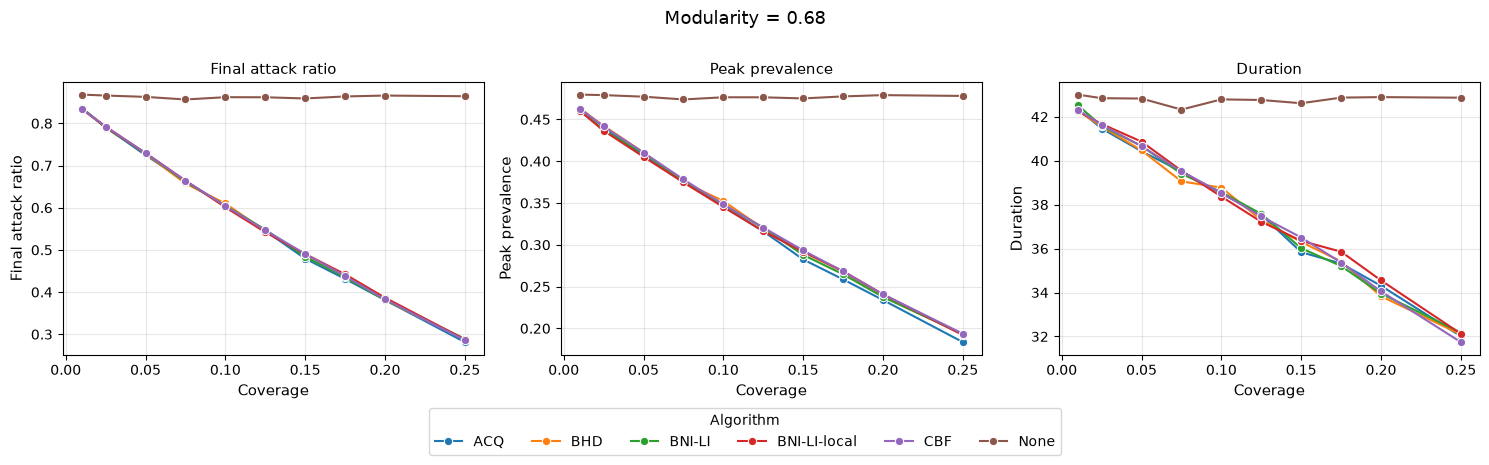

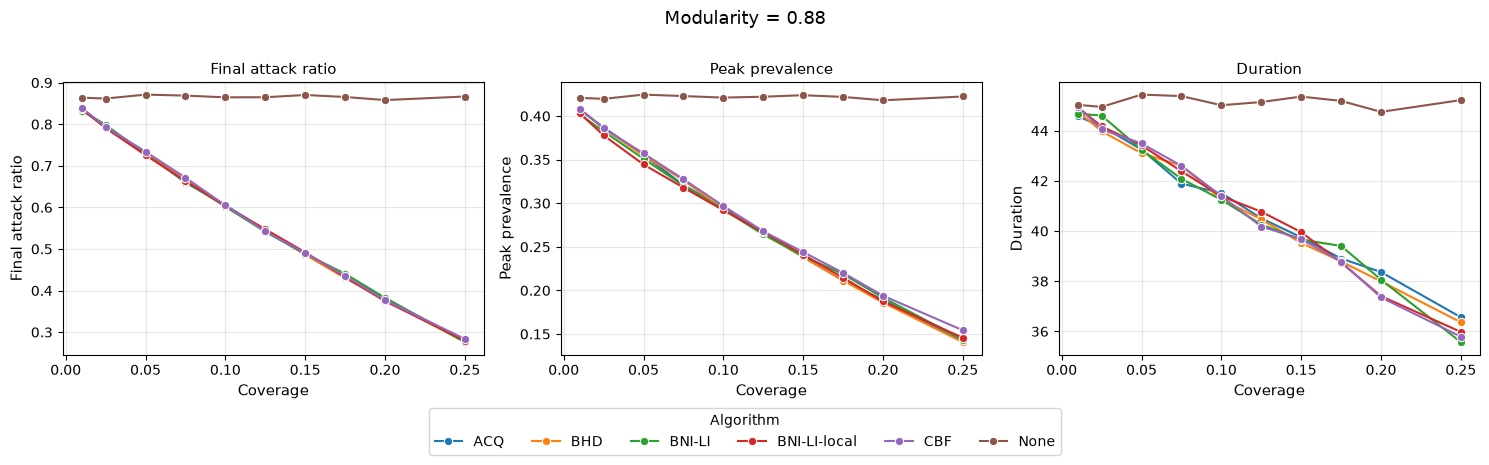

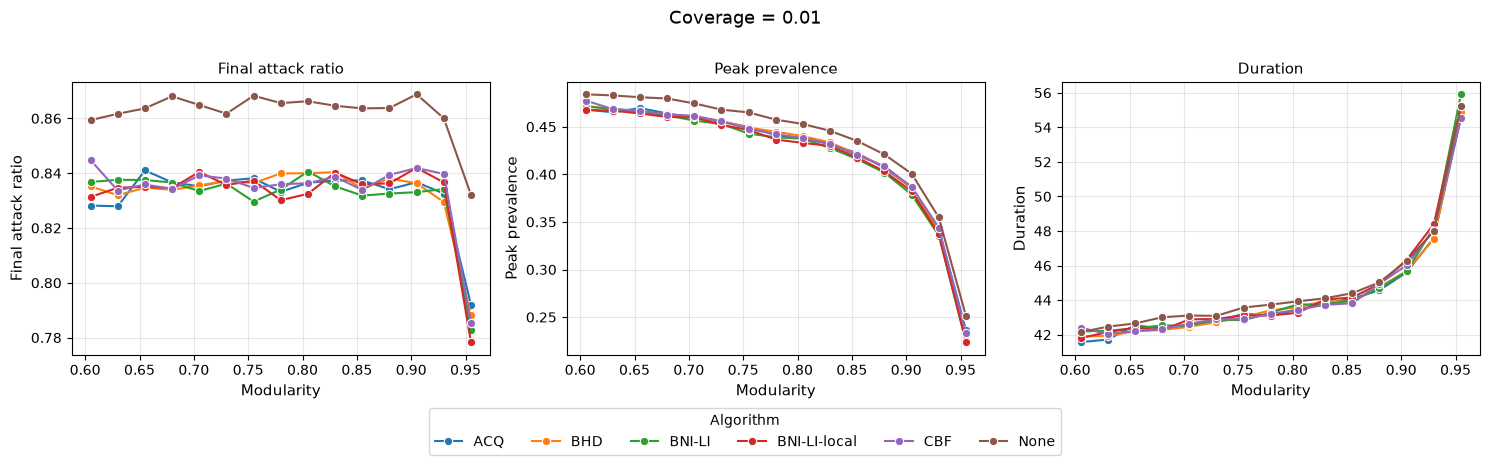

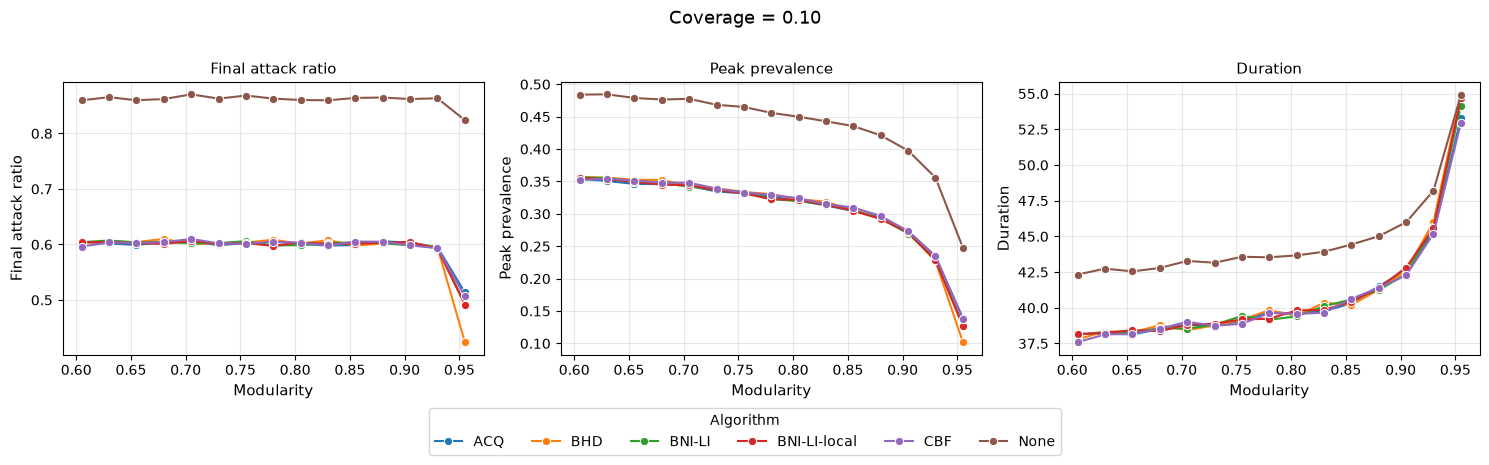

In [36]:
# filter for beta/gamma slice
df_sub = df_avg.query(f"beta == {BETA_SLICE} and gamma == {GAMMA_SLICE}")

# Build a rewire_steps → mean modularity lookup for readable slice labels.
rewire_to_mod = df_sub.groupby("rewire_steps")["modularity"].mean().round(2)

# Metric vs. coverage, for selected modularity (rewire_steps) levels 
for rw in REWIRE_LEVELS:
    subset  = df_sub.query("rewire_steps == @rw")
    mod_val = rewire_to_mod.loc[rw]
    plot_metrics(
        subset,
        x_col="coverage",
        slice_col="modularity",
        slice_val=mod_val,
        x_label="Coverage",
        slice_label="Modularity",
        save_path=f"figures/metric_vs_coverage_mod{mod_val}.png",
    )

# Metric vs. modularity, for selected coverage levels 
for cov in COVERAGE_LEVELS:
    subset = df_sub.query("coverage == @cov")
    plot_metrics(
        subset,
        x_col="modularity",
        slice_col="coverage",
        slice_val=cov,
        x_label="Modularity",
        slice_label="Coverage",
        save_path=f"figures/metric_vs_modularity_cov{cov}.png",
    )

In [37]:
def pairwise_comparison(df, algo_A, algo_B, metric_map, metric_var_map=None, row="coverage", col_="modularity"):
    """Perform pairwise comparison of two algorithms across all parameter combos. Produces one plot per beta-gamma slice
    found in the df, showing the difference in each metric between the two algorithms as a heatmap over the (coverage, modularity) grid.

    Parameters
    ----------
    df      : DataFrame with columns 'algorithm', 'coverage', 'modularity', and metric columns
    algo_A  : name of first algorithm (must be present in df['algorithm'])
    algo_B  : name of second algorithm (must be present in df['algorithm'])
    metric_map : dict mapping output column names to metric column names, e.g. {"alg_final": "final_attack_ratio"}
    row      : column name to use as heatmap rows (default 'coverage')
    col_     : column name to use as heatmap columns (default 'modularity')

    Returns
    -------
    """
    algo_list = [algo_A, algo_B]
    # filter to only the two algorithms we're comparing
    df_algs = df.query("algorithm in @algo_list")
    print(f"Comparing algorithms: {algo_A} vs {algo_B}")

    # normalize beta/gamma to two decimals before iterating; avoids float noise in labels
    slices = (
        df_algs[["beta", "gamma"]]
               .round({"beta": 2, "gamma": 2})
               .drop_duplicates()
               .reset_index(drop=True)
    )

    for beta, gamma in slices.itertuples(index=False):
        beta = float(round(beta, 2))
        gamma = float(round(gamma, 2))

        df_slice = df_algs.loc[
            df_algs["beta"].round(2).eq(beta) &
            df_algs["gamma"].round(2).eq(gamma)
        ]

        pivot = df_slice.pivot_table(
            index=["coverage", "modularity"],
            columns="algorithm",
            values=METRICS,
            aggfunc="mean"
        ).reset_index()

        fig, axes = plt.subplots(ncols=len(METRICS), figsize=(15, 5))
        fig.suptitle(f"{algo_A} vs {algo_B} (β={beta:.2f}, γ={gamma:.2f})", fontsize=14)
        for metric in METRICS:
            pivot[f"{metric}_diff"] = pivot[(metric, algo_A)] - pivot[(metric, algo_B)]
            ax = axes[METRICS.index(metric)]
            sns.heatmap(
                pivot.pivot(index=row, columns=col_, values=f"{metric}_diff"),
                cmap="RdBu_r",
                center=0,
                #annot=True,
                fmt=".2f",
                ax=ax
            )
            ax.invert_yaxis() # bc otherwise lowest coverage is at the top somehow??
            if metric_var_map is None:
                ax.set_title(f"Difference in {metric_map[metric]} ({algo_A} - {algo_B})")
            else:
                ax.set_title(f"Difference in {metric_map[metric]} (${metric_var_map[metric]}_{{\\mathrm{{{algo_A}}}}}$ - ${metric_var_map[metric]}_{{\\mathrm{{{algo_B}}}}}$)")
            ax.set_xlabel(col_)
            ax.set_ylabel(row)

        fig.tight_layout()
        fig.savefig(f"figures/pairwise_comparison_{algo_A}_vs_{algo_B}_beta{beta:.2f}_gamma{gamma:.2f}.png", dpi=400)   
        plt.show()


In [38]:
rewire_to_mod = df_avg.groupby("rewire_steps")["modularity"].mean().round(2)
df_avg["modularity"] = df_avg["rewire_steps"].map(rewire_to_mod)

Note to self: Red = Second algorithm is better, Blue = First algorithm is better

Comparing algorithms: CBF vs BHD


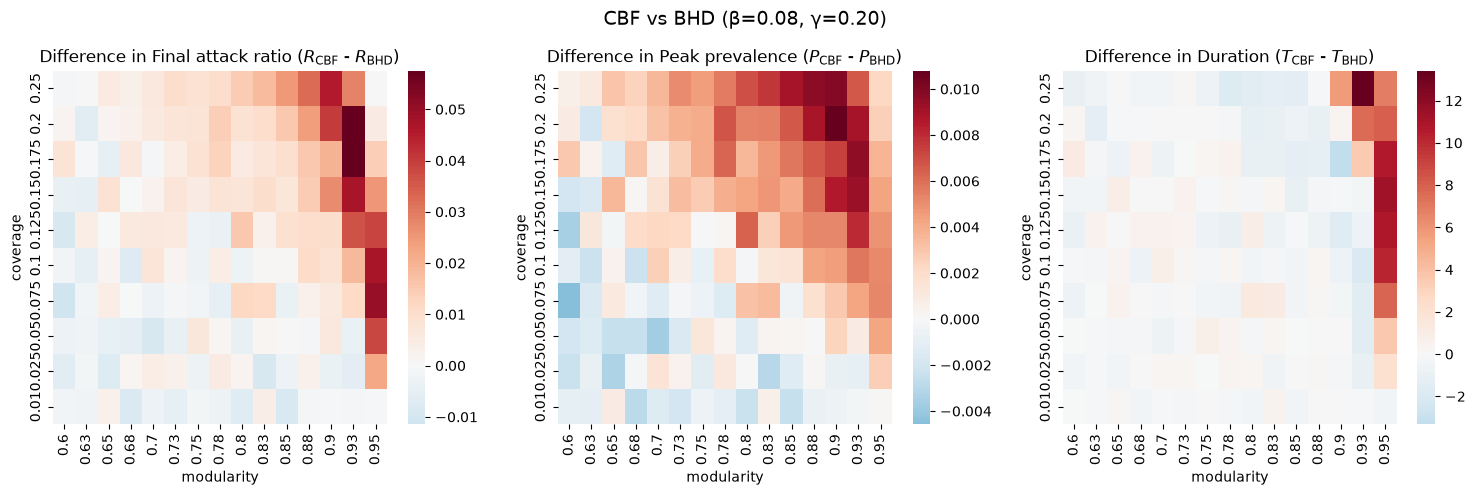

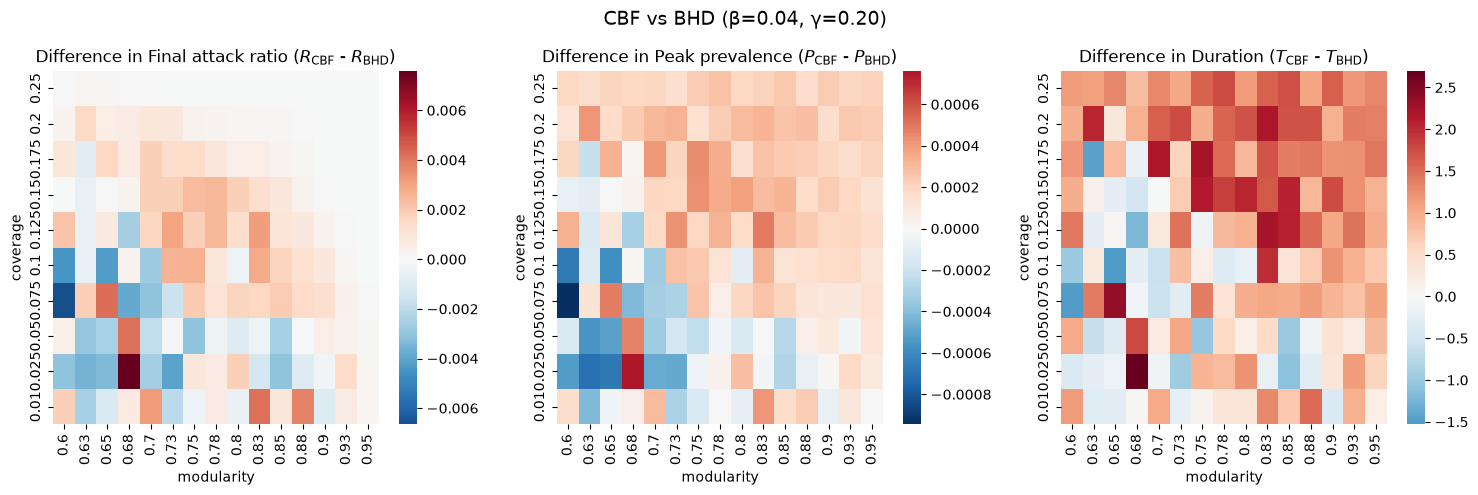

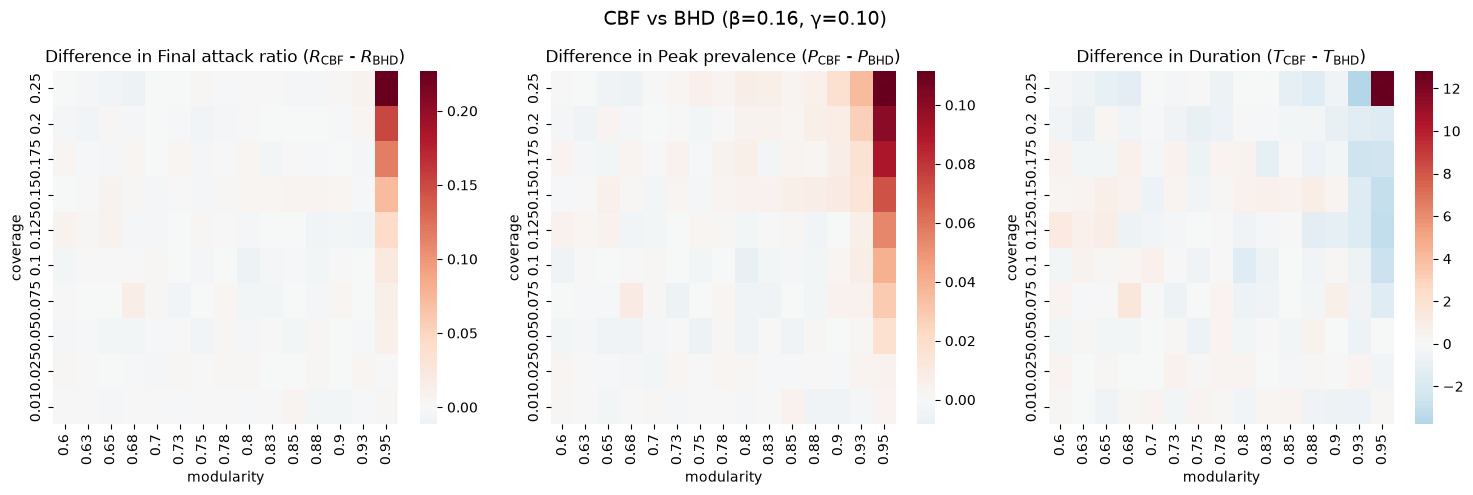

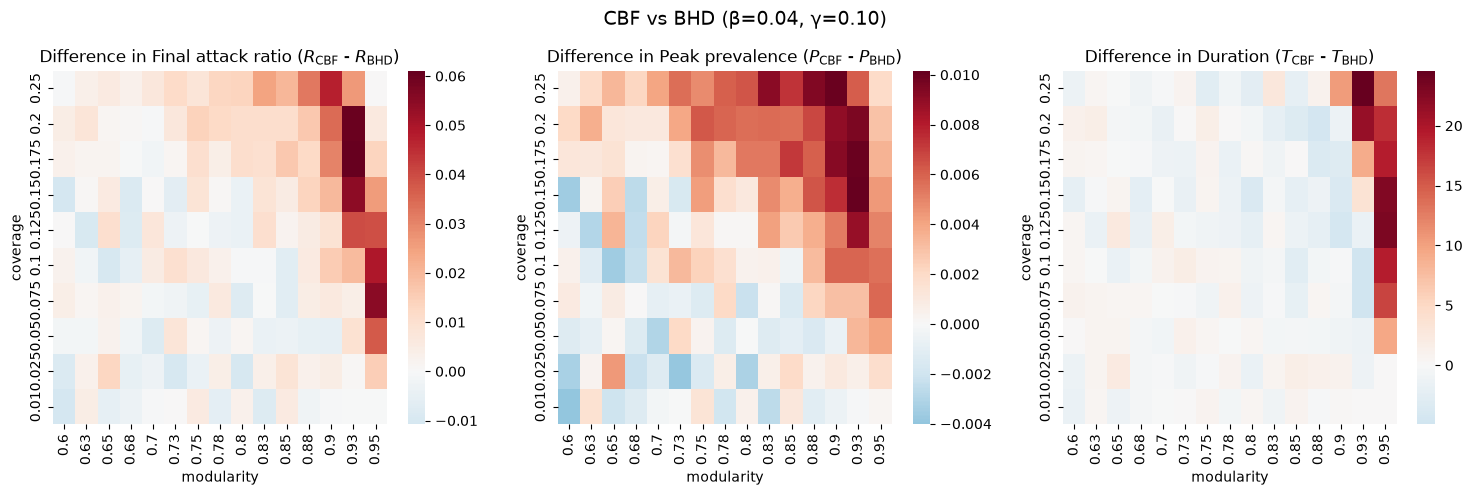

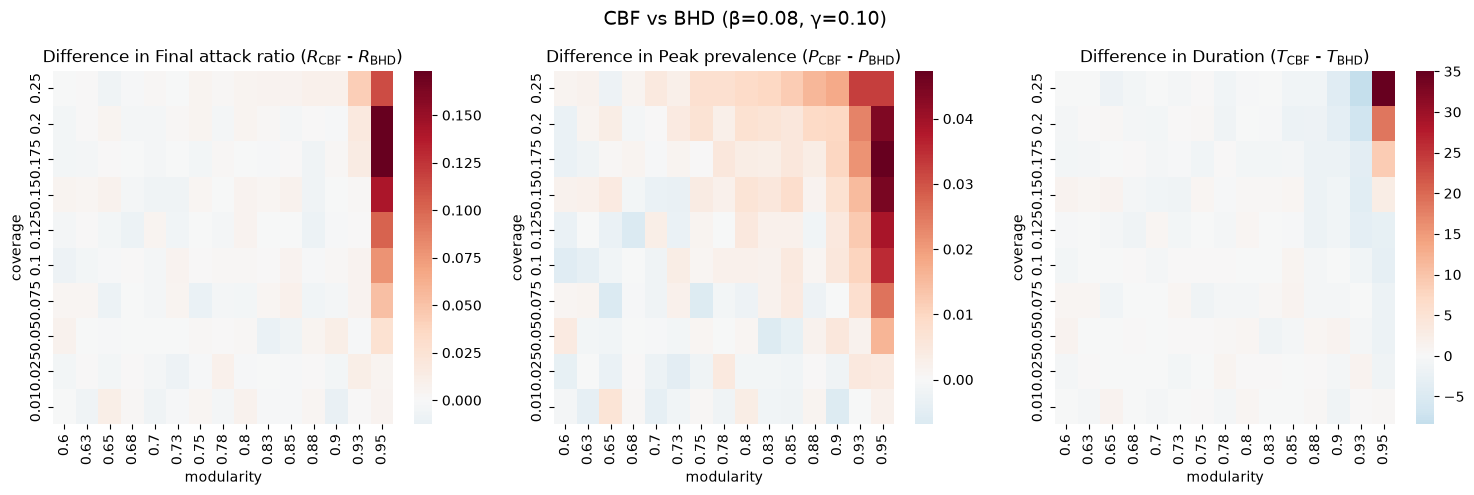

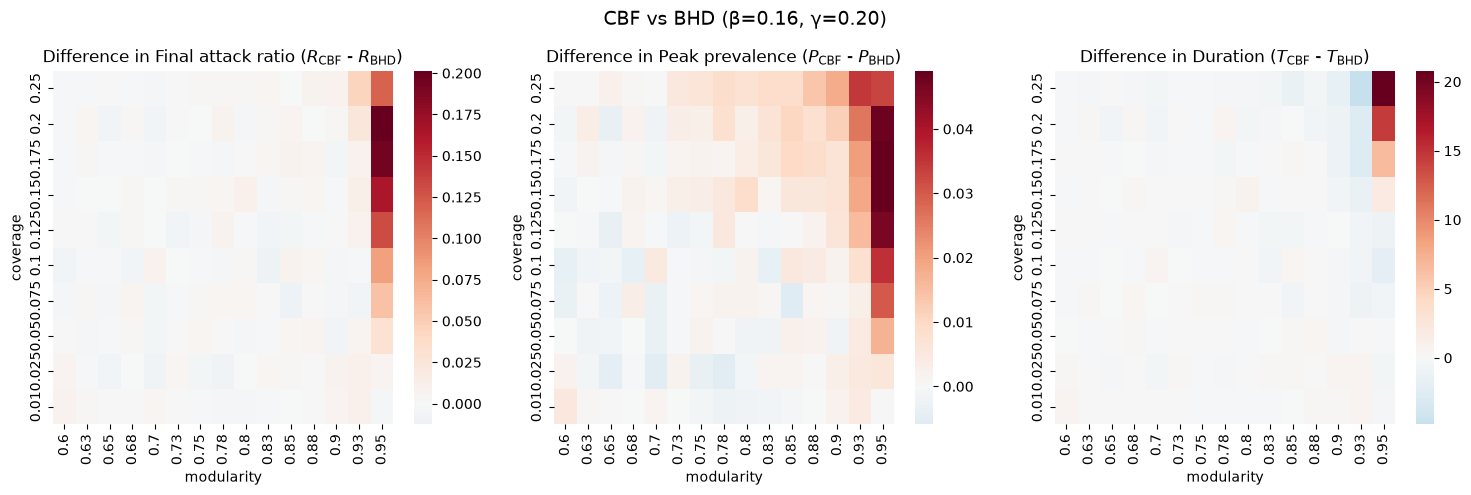

In [39]:
pairwise_comparison(df_avg, 'CBF', 'BHD', METRIC_LABELS, METRIC_VAR_MAP)

Comparing algorithms: CBF vs BNI-LI


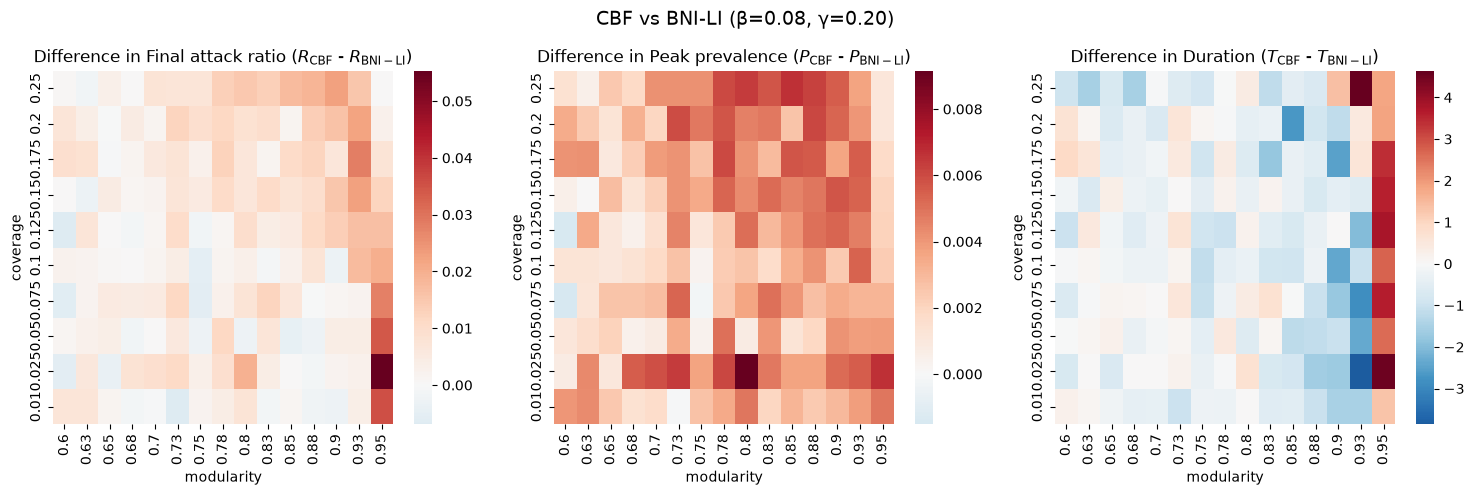

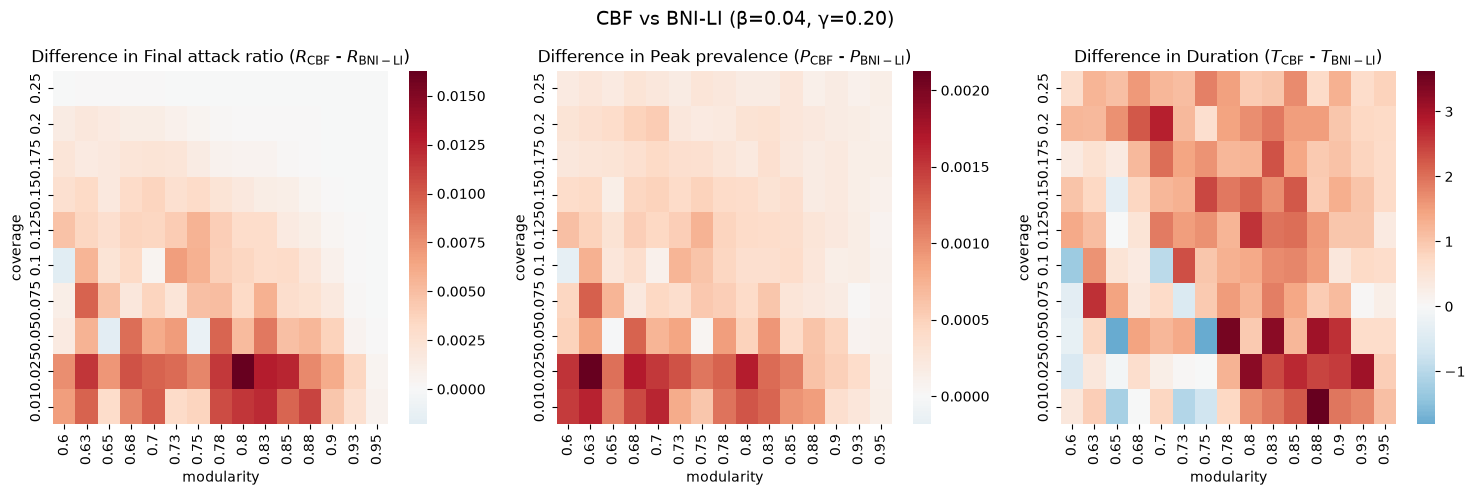

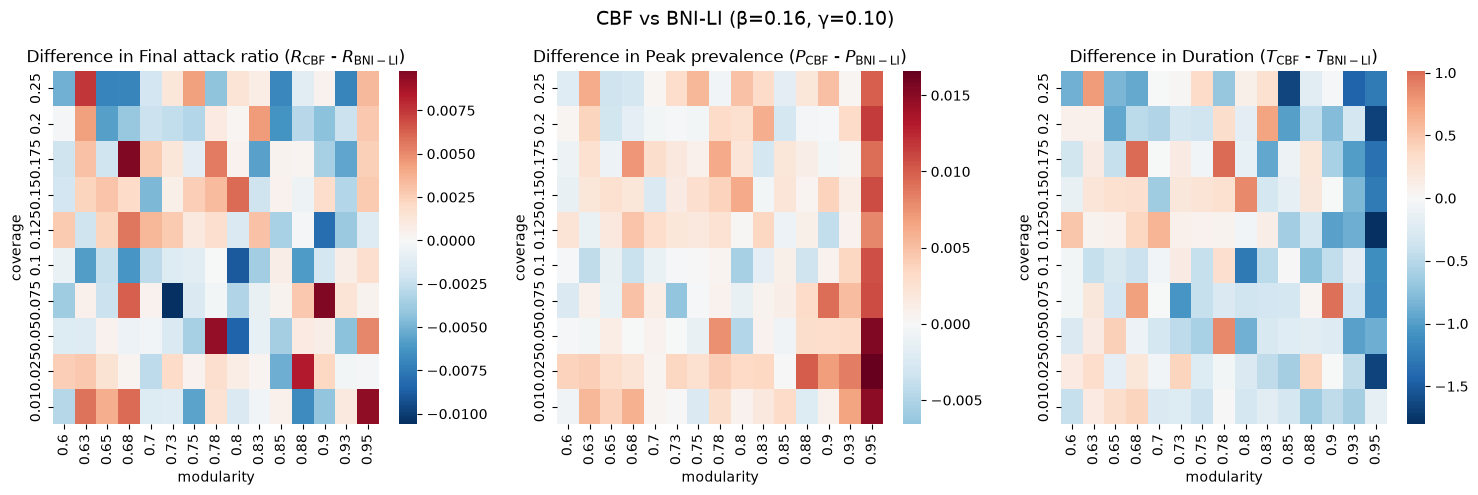

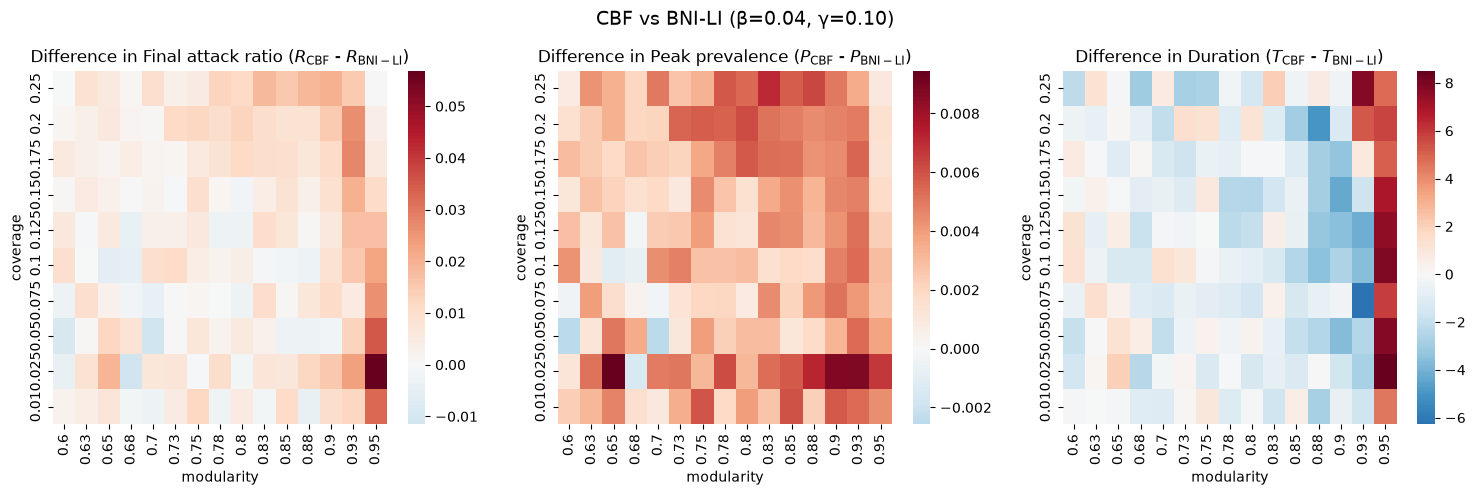

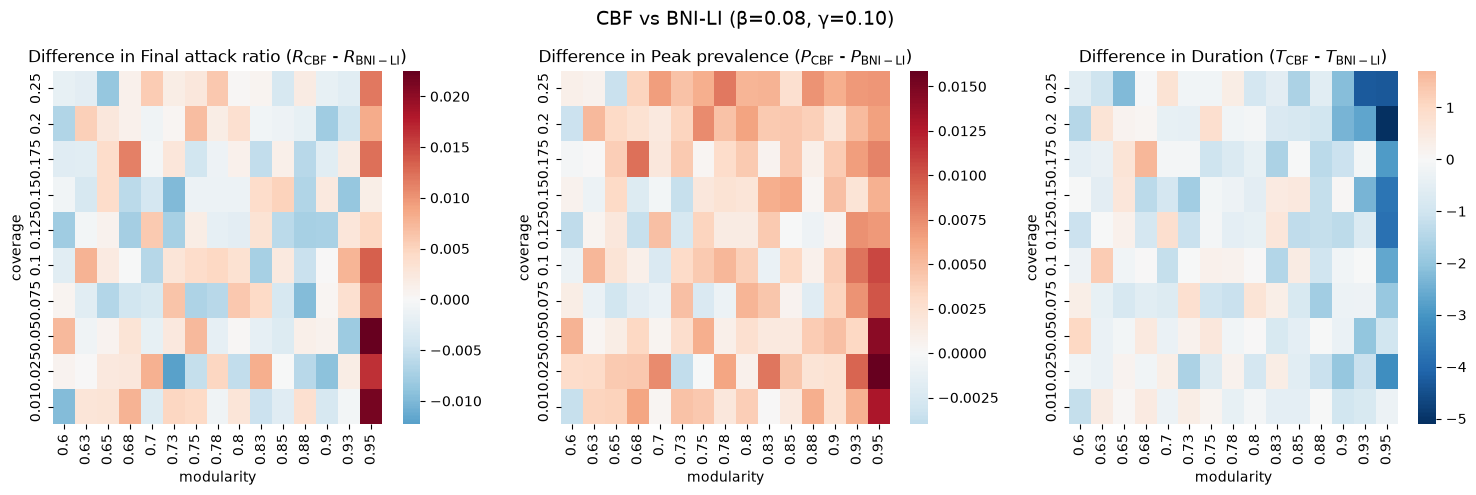

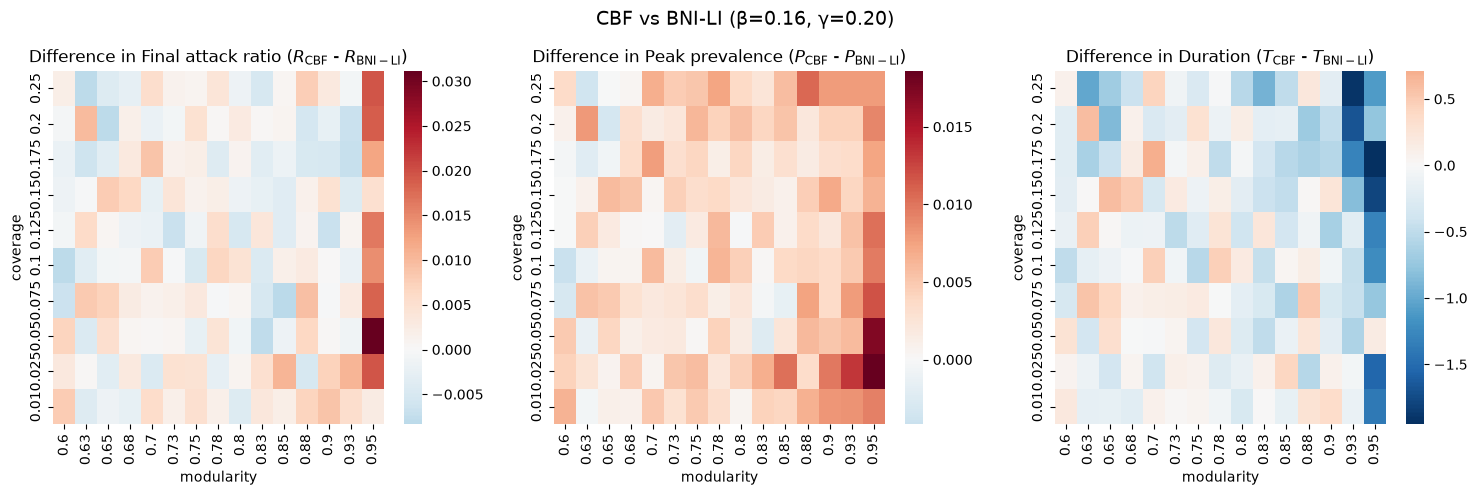

In [40]:
pairwise_comparison(df_avg, 'CBF', 'BNI-LI', METRIC_LABELS, METRIC_VAR_MAP)

Comparing algorithms: CBF vs BNI-LI-local


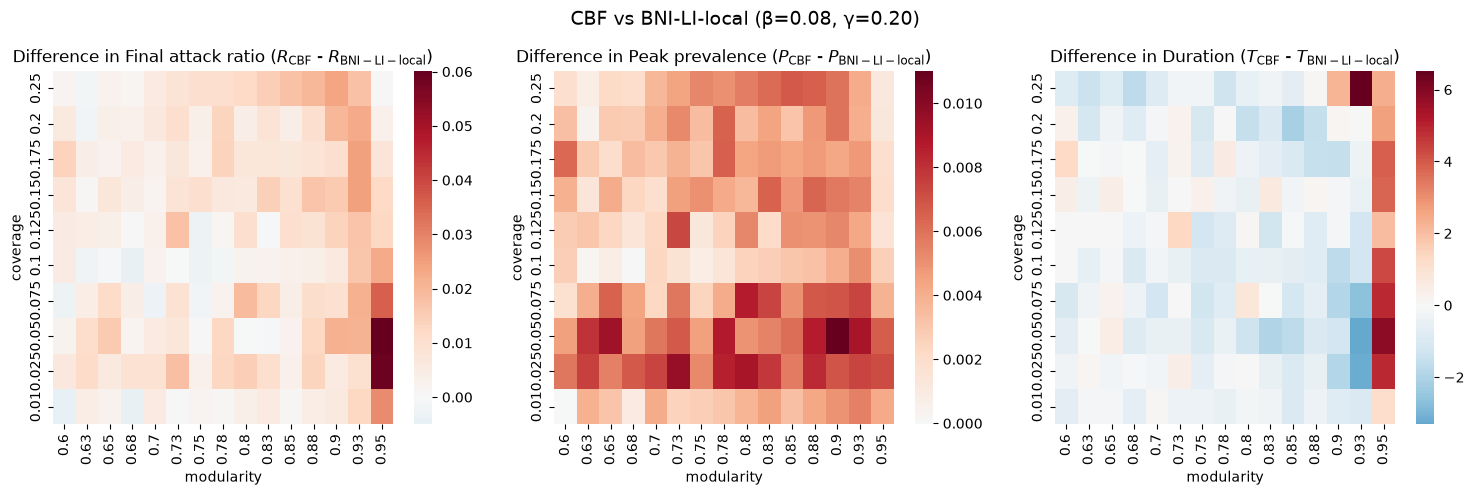

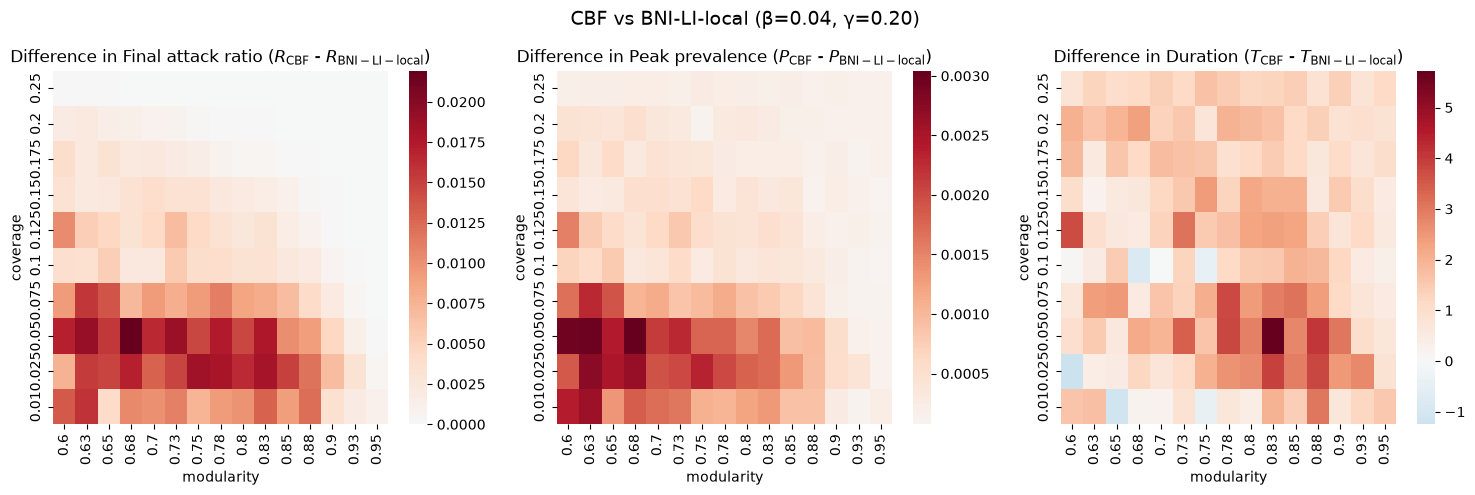

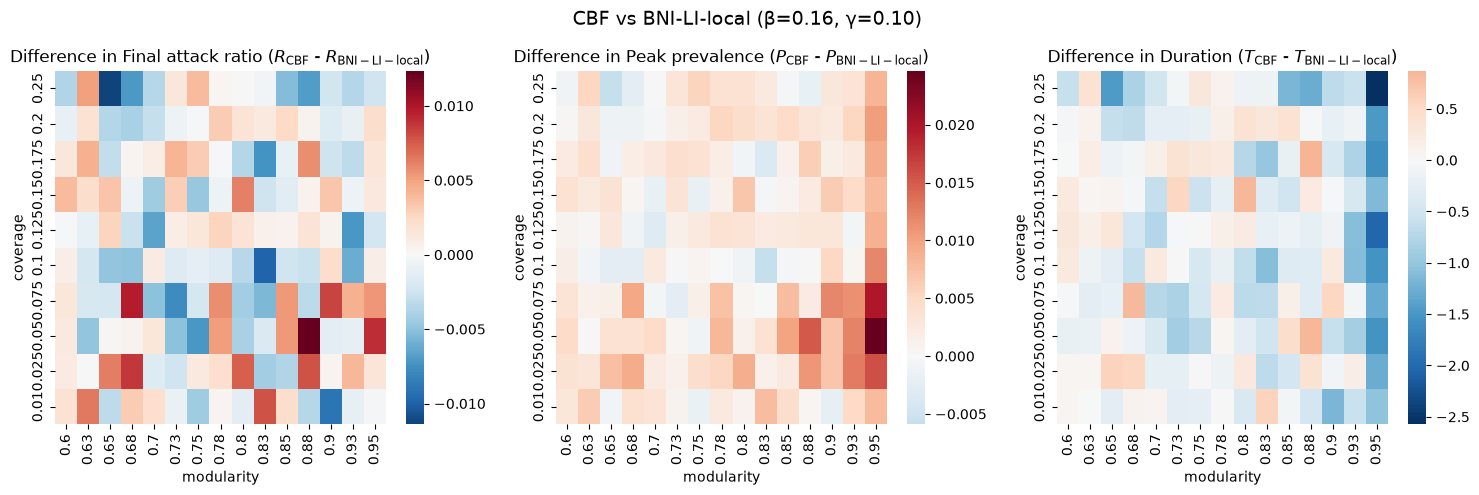

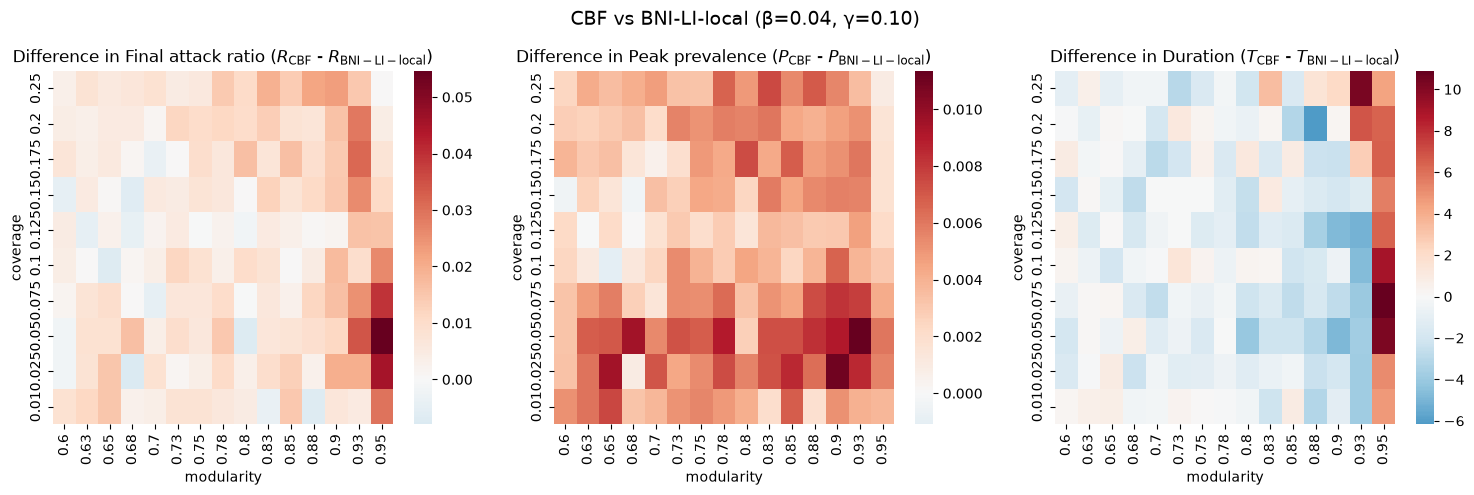

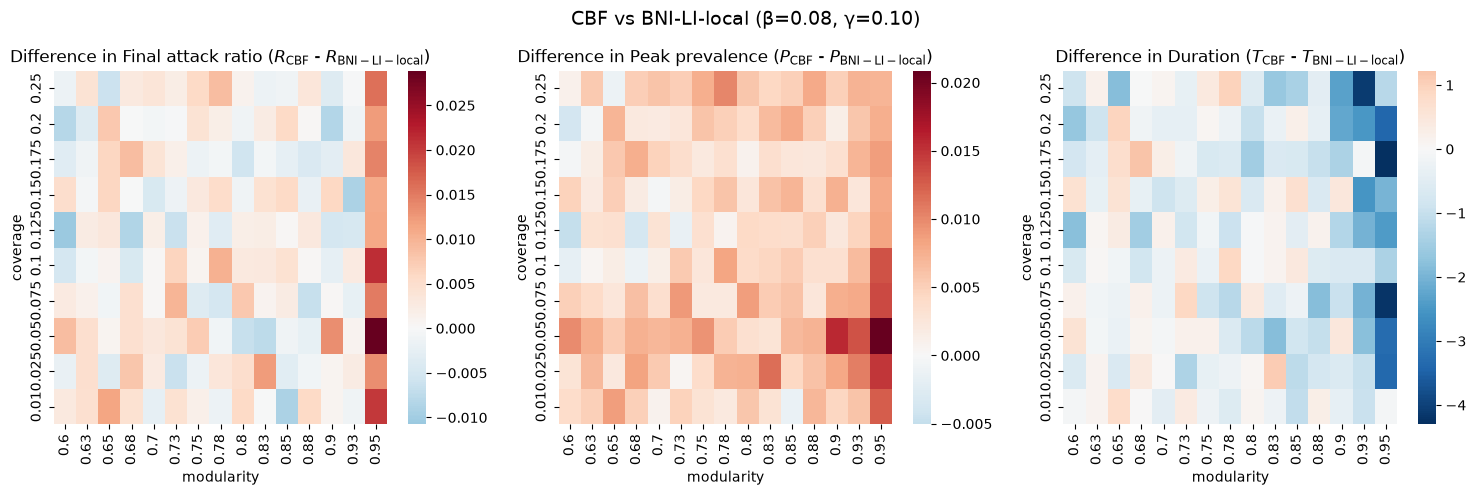

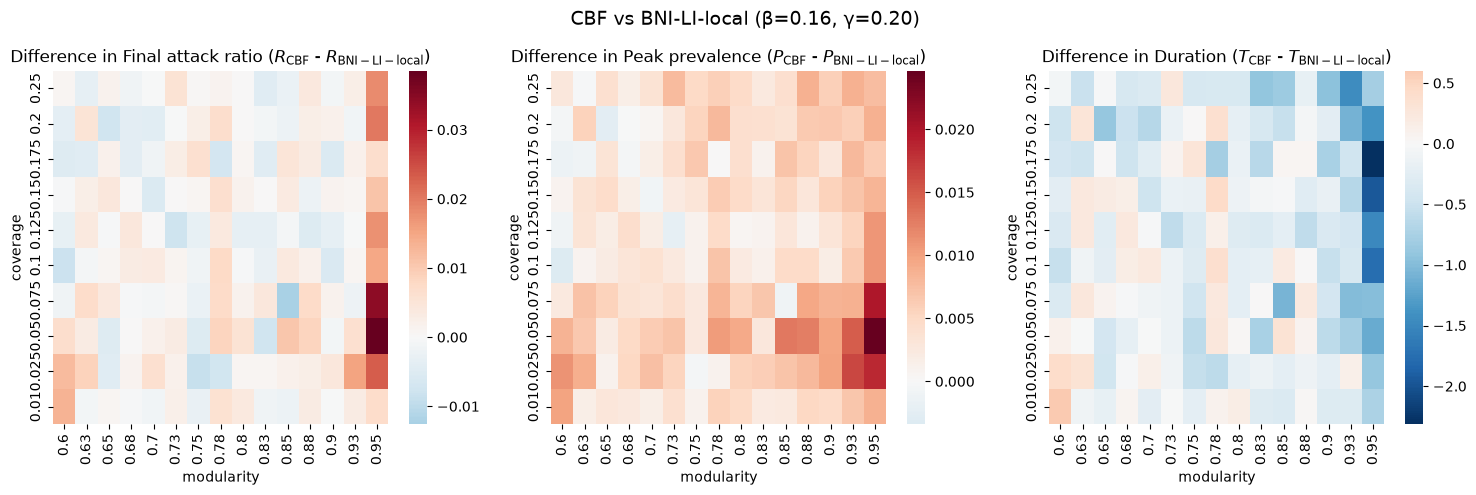

In [41]:
pairwise_comparison(df_avg, 'CBF', 'BNI-LI-local', METRIC_LABELS, METRIC_VAR_MAP)

Comparing algorithms: ACQ vs CBF


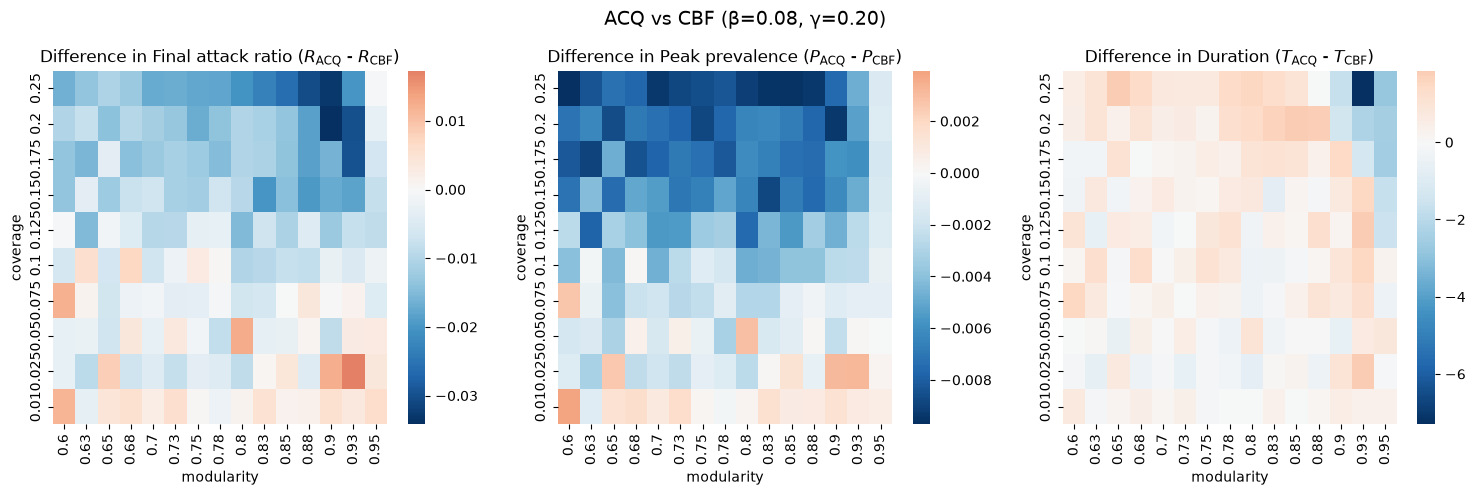

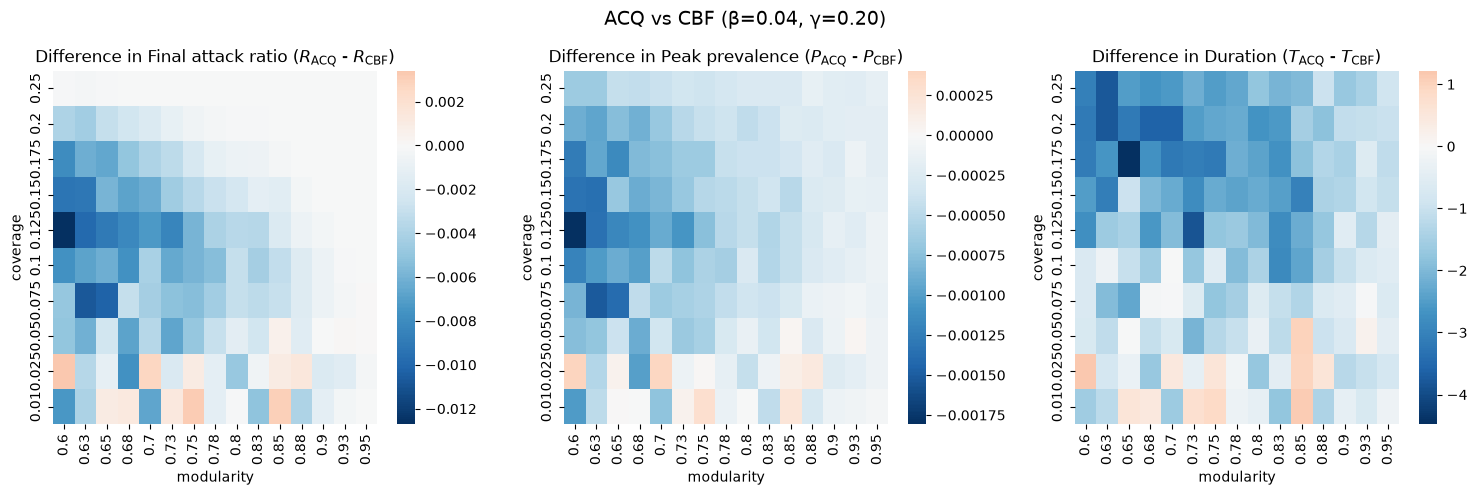

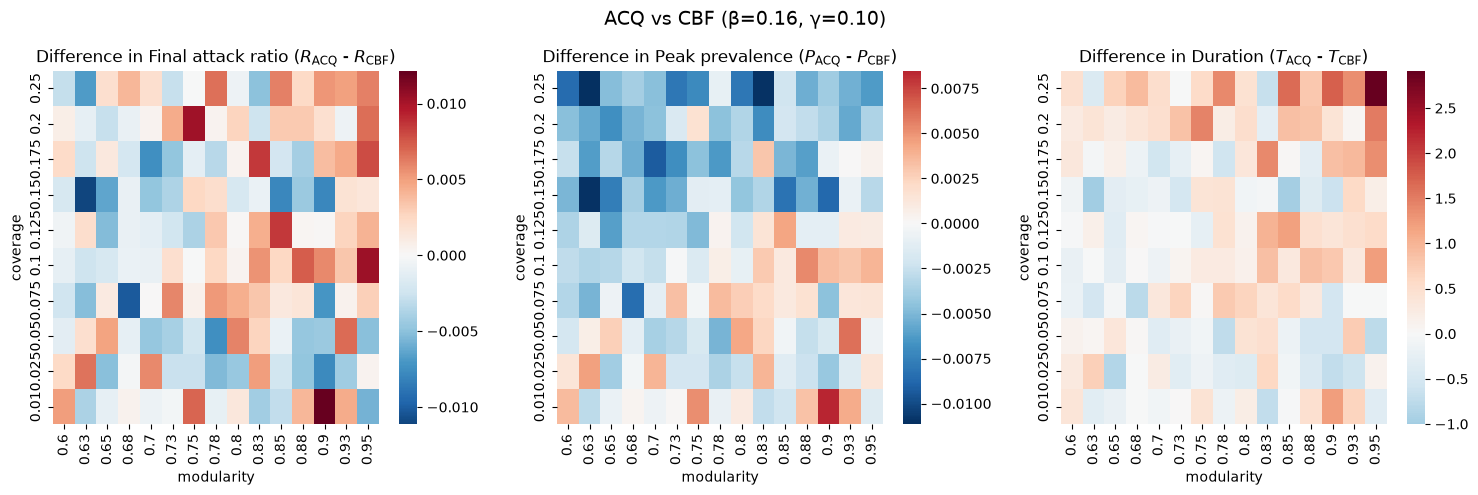

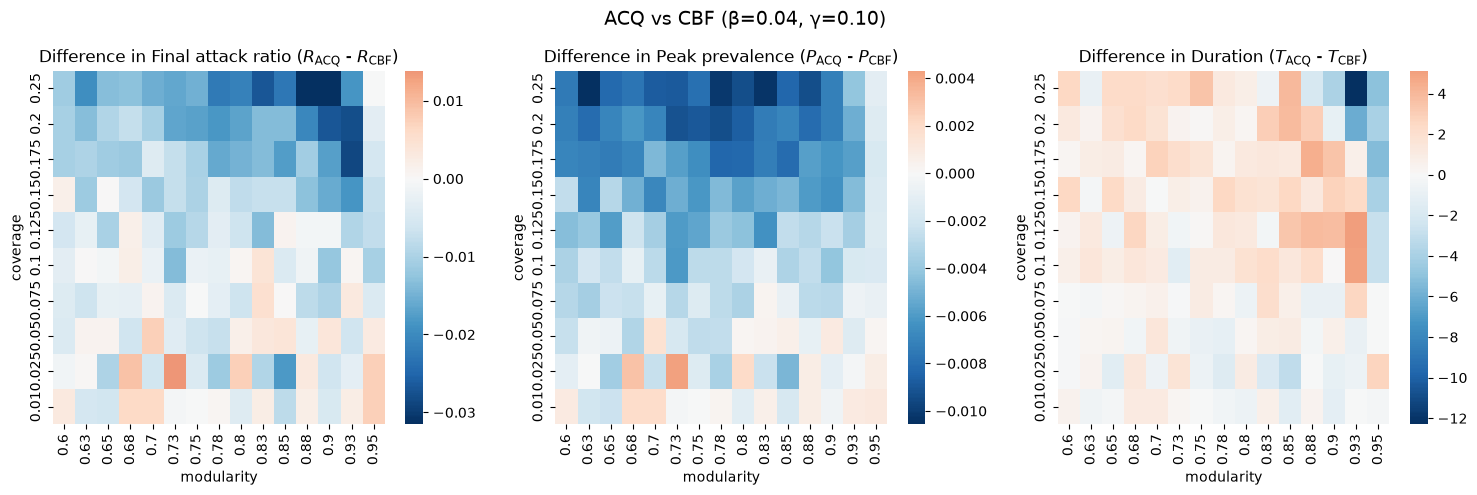

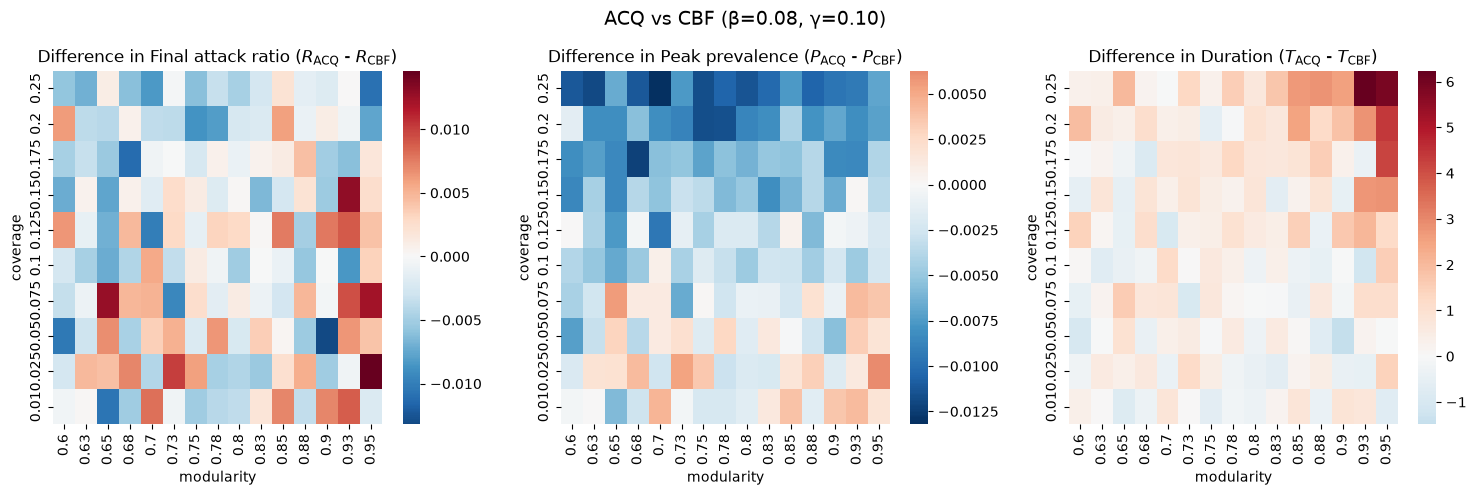

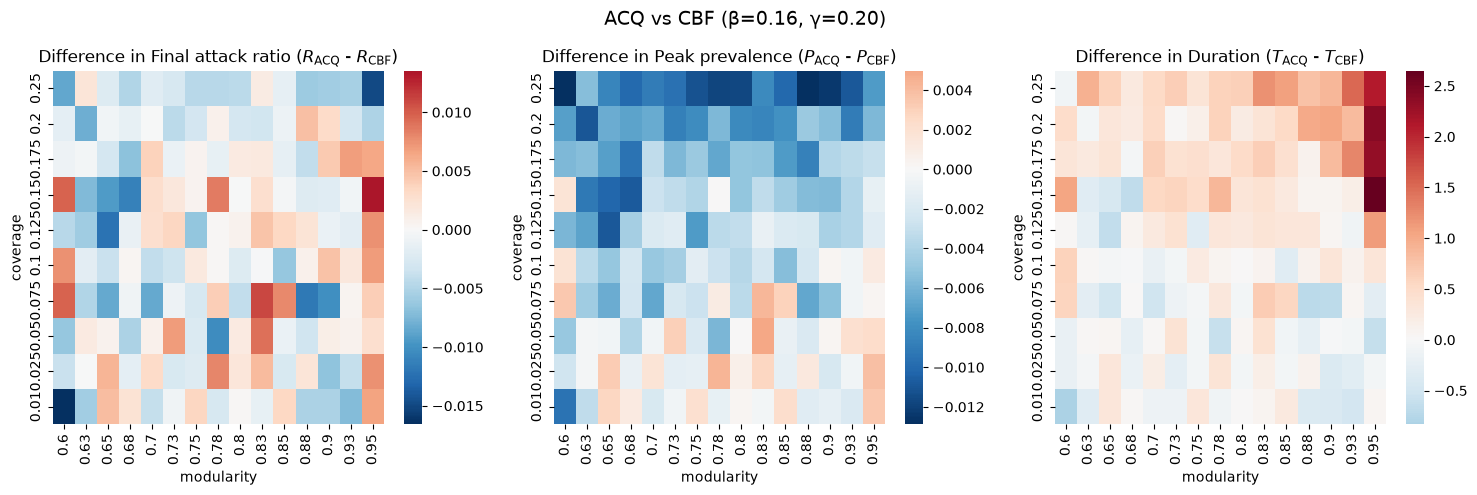

In [42]:
pairwise_comparison(df_avg, 'ACQ', 'CBF', METRIC_LABELS, METRIC_VAR_MAP)

Comparing algorithms: BHD vs BNI-LI


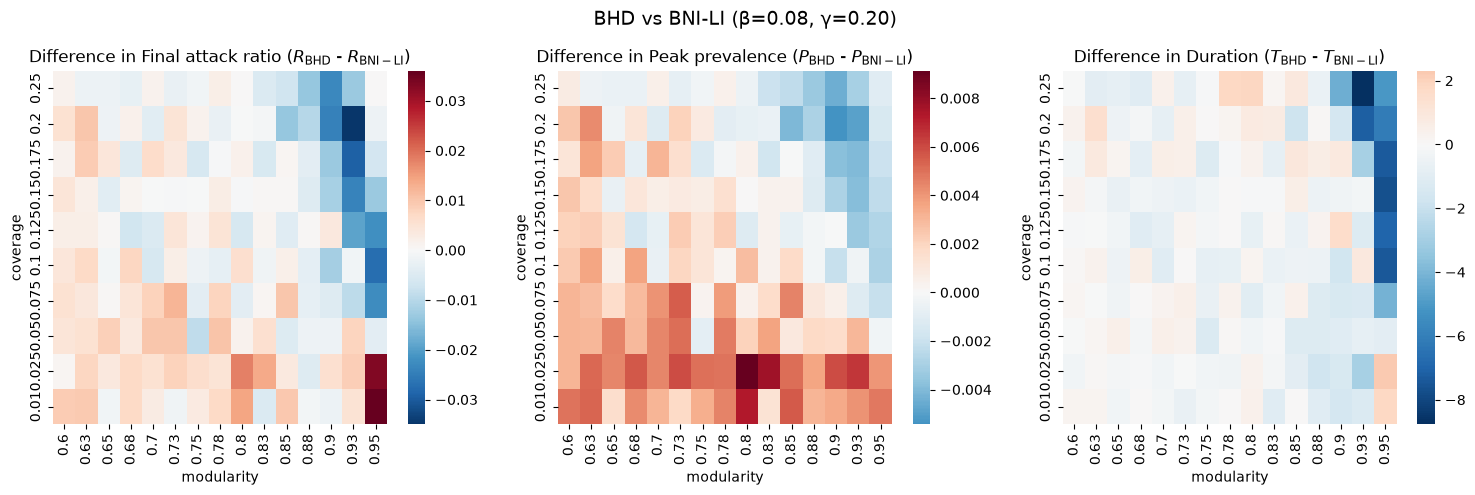

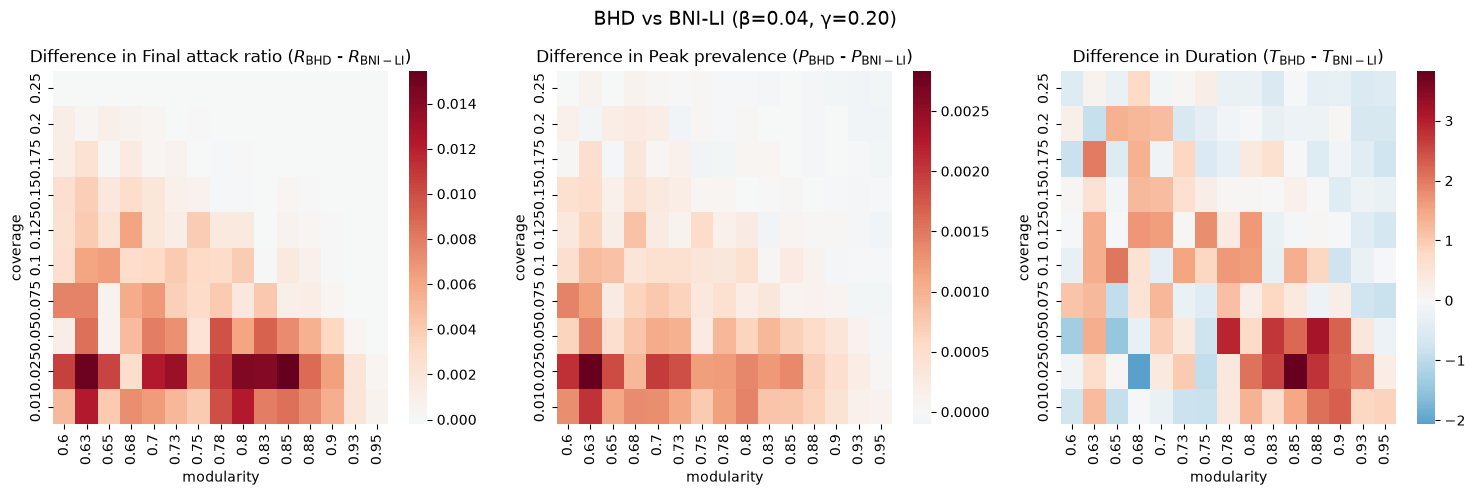

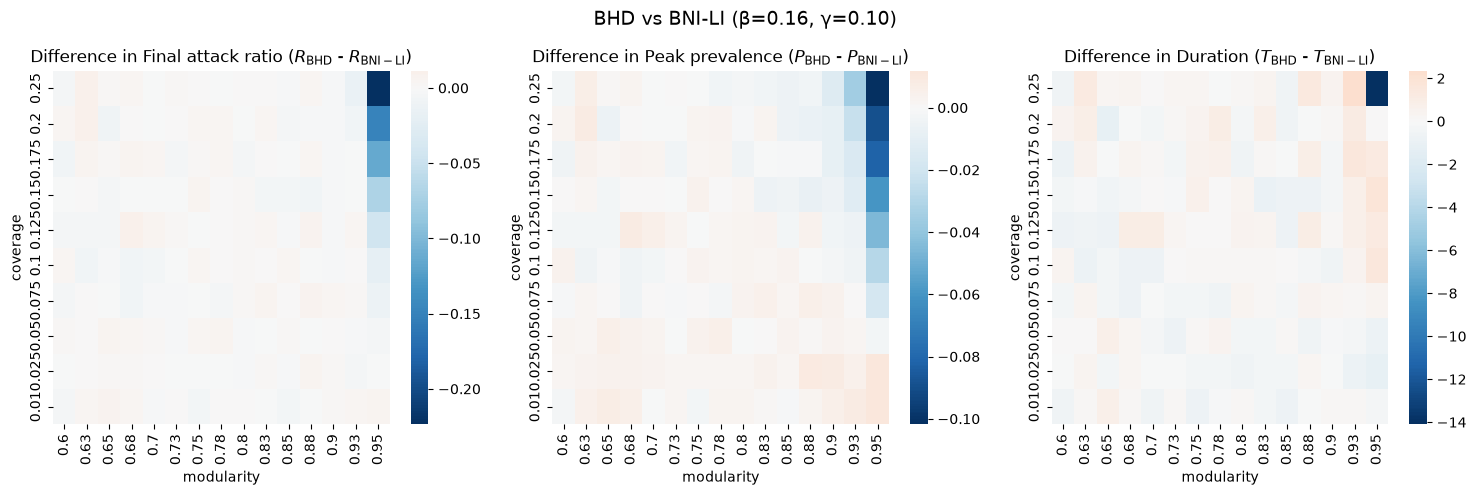

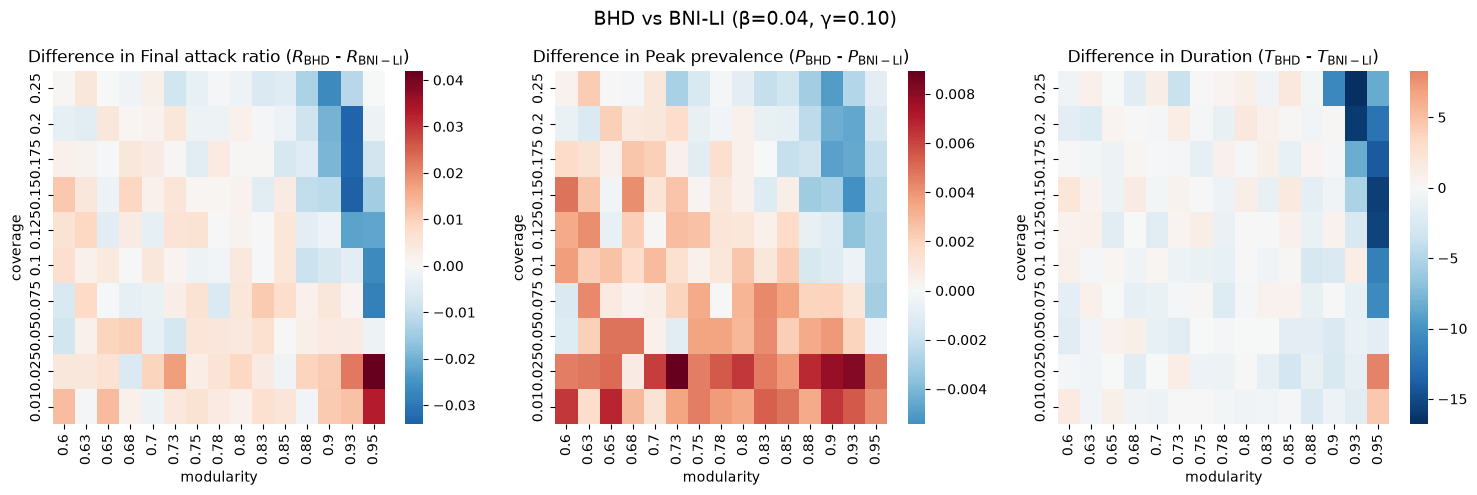

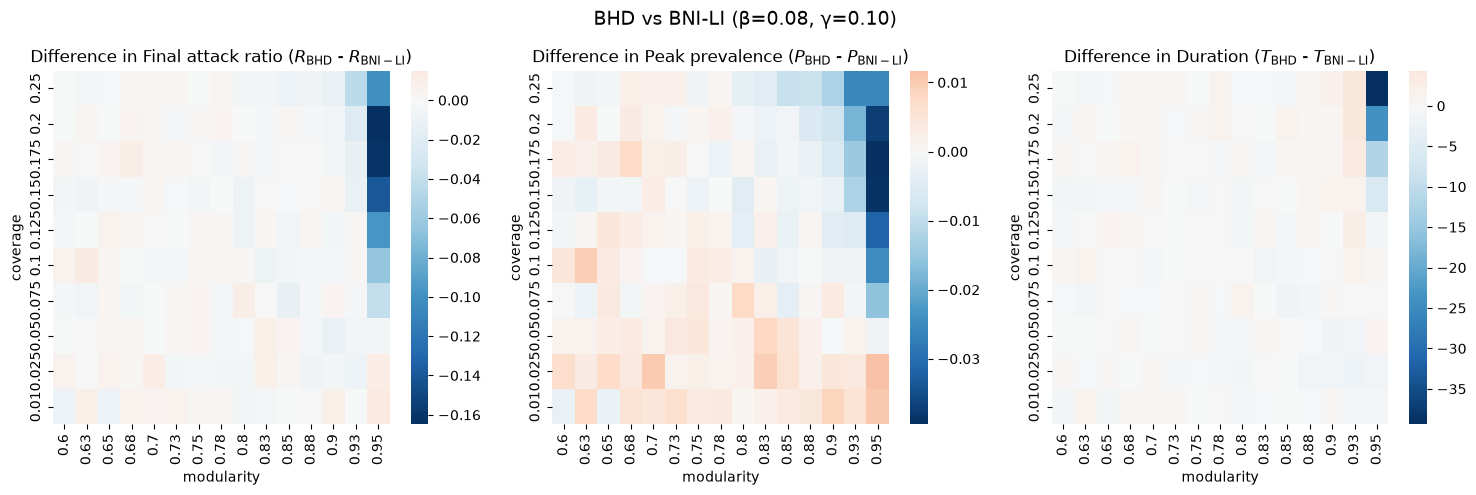

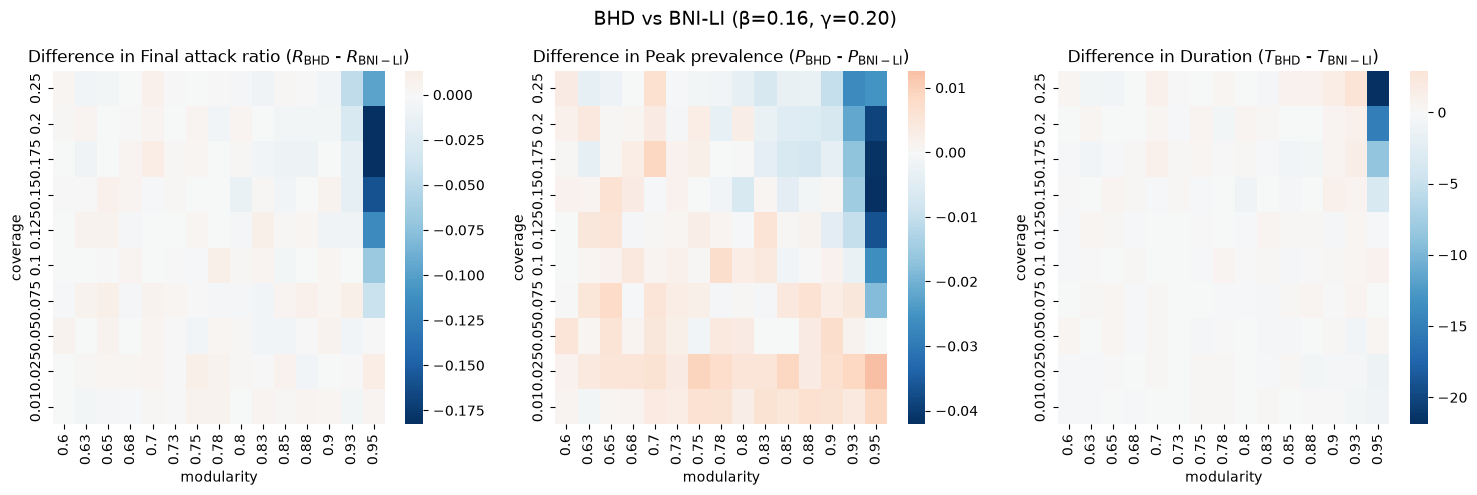

In [43]:
pairwise_comparison(df_avg, 'BHD', 'BNI-LI', METRIC_LABELS, METRIC_VAR_MAP)

Comparing algorithms: BHD vs BNI-LI-local


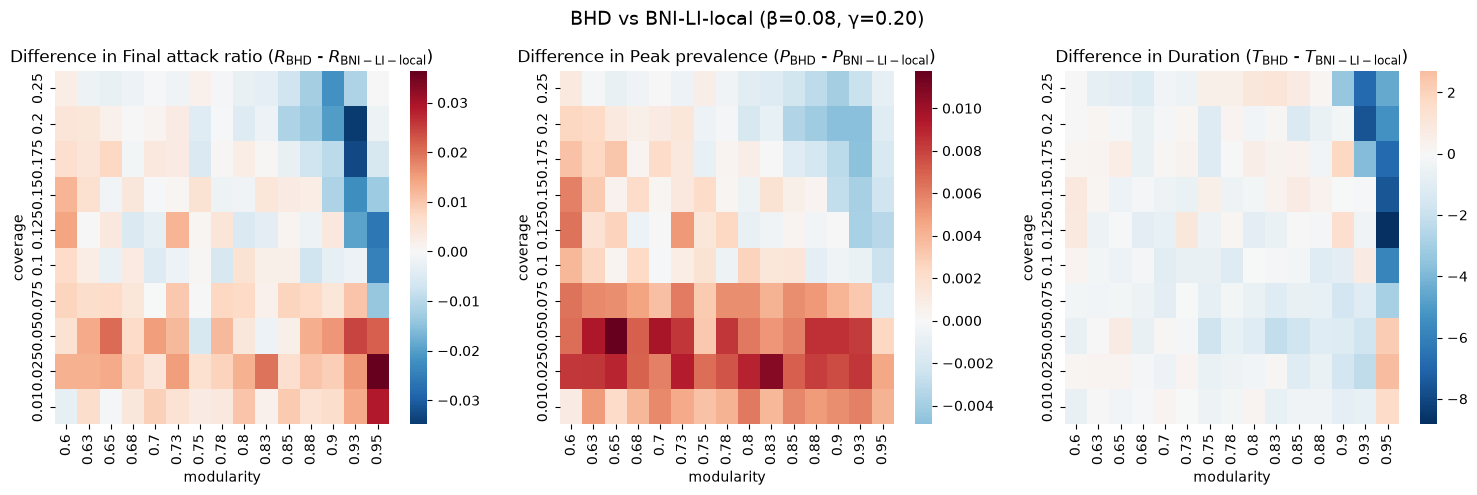

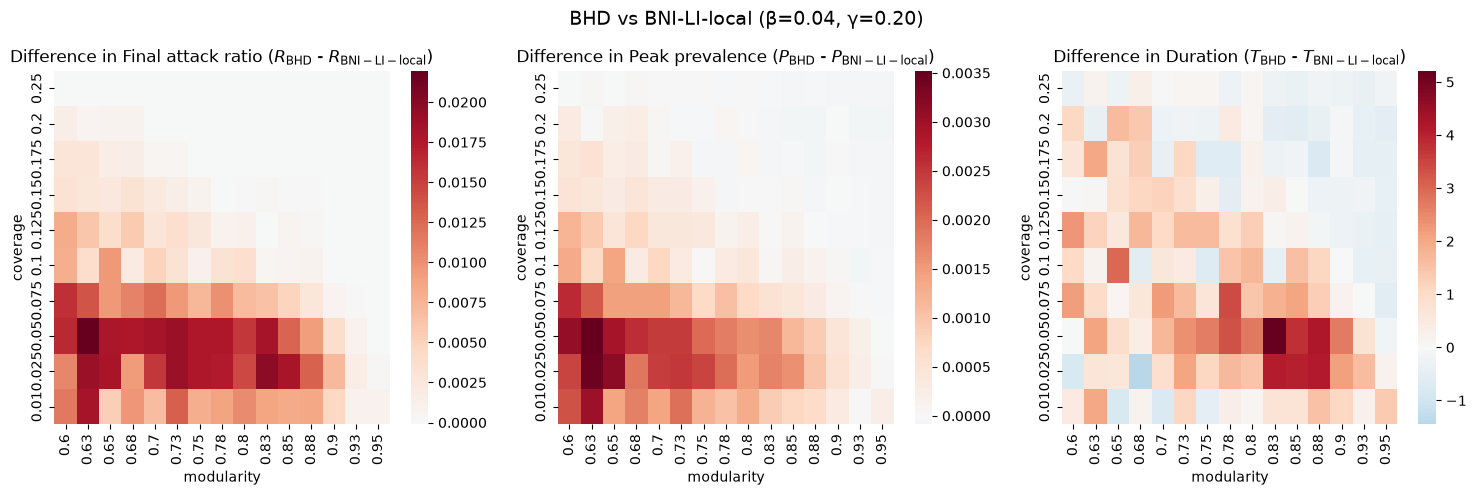

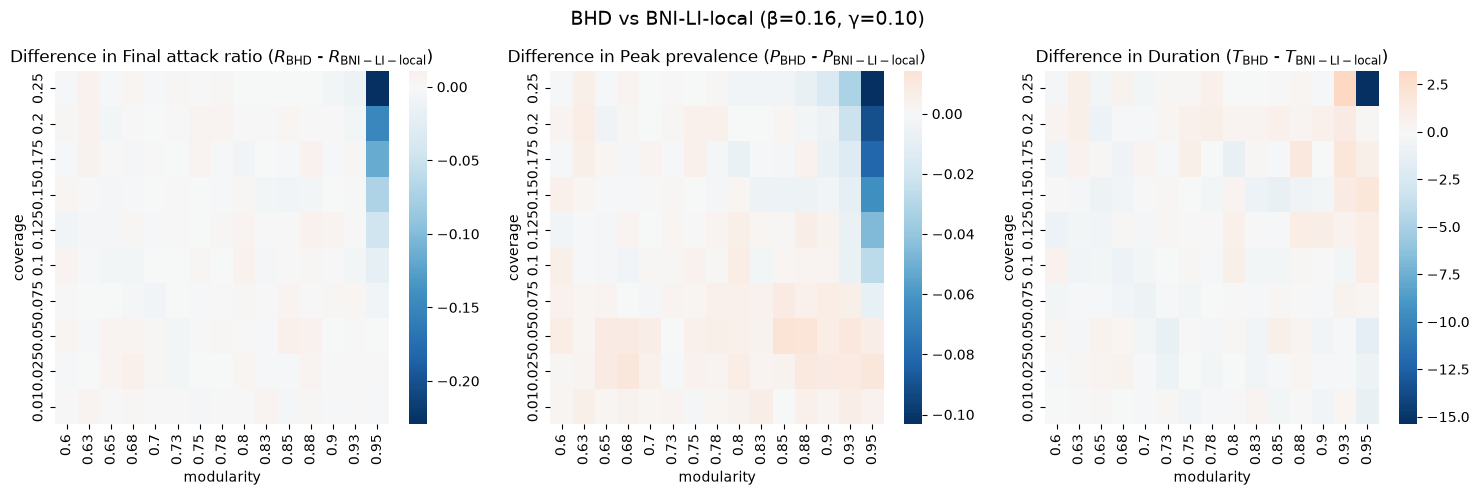

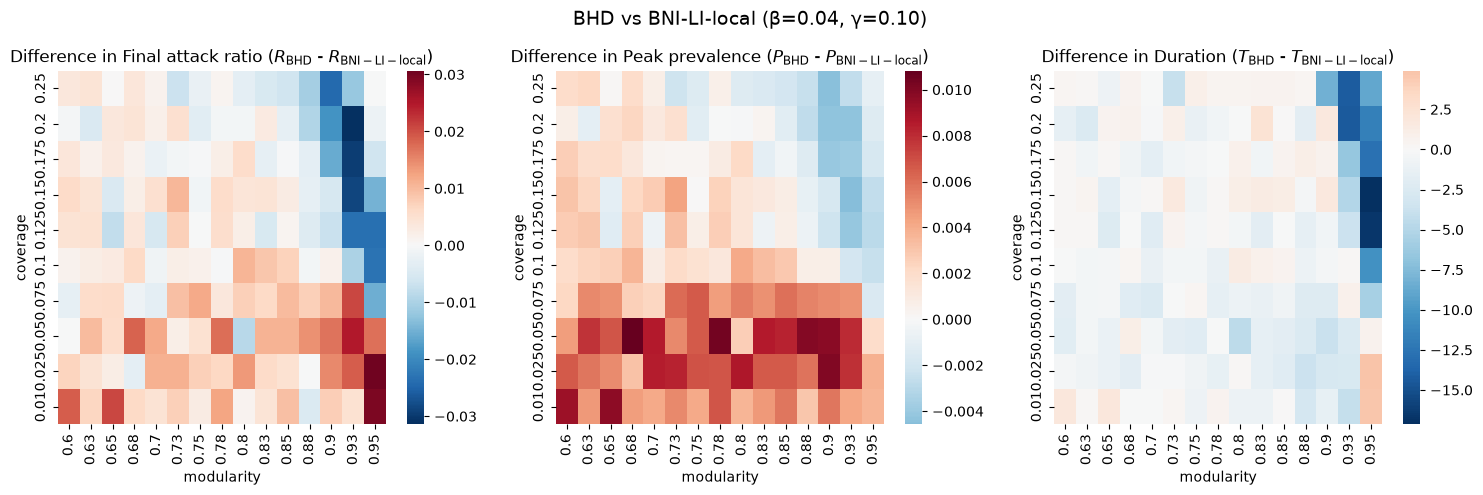

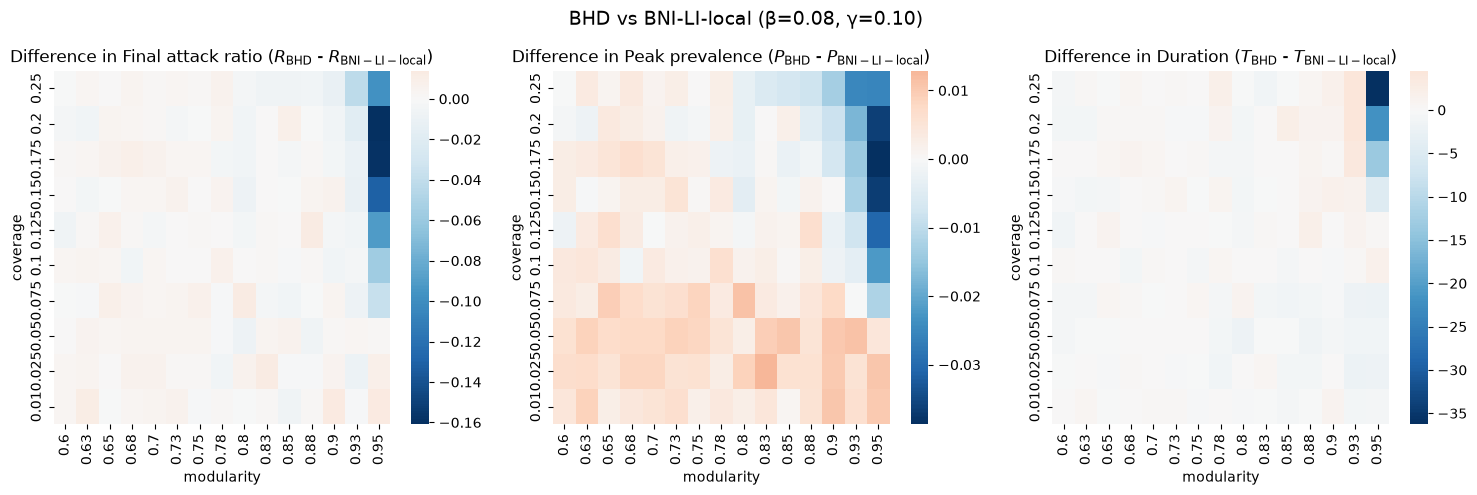

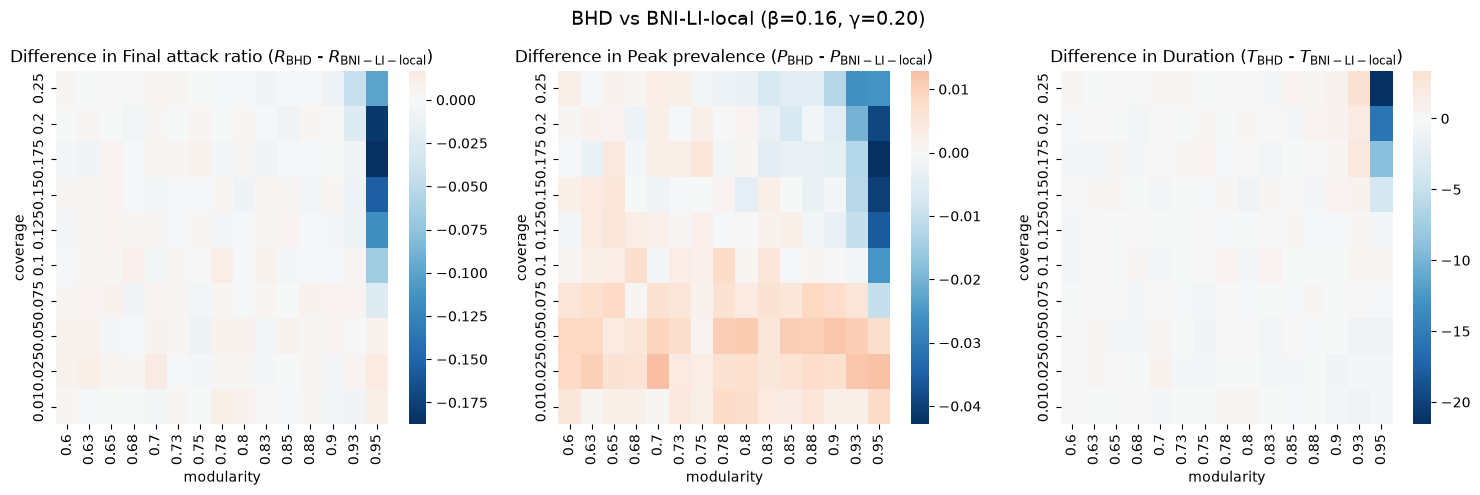

In [44]:
pairwise_comparison(df_avg, 'BHD', 'BNI-LI-local', METRIC_LABELS, METRIC_VAR_MAP)

Comparing algorithms: ACQ vs BHD


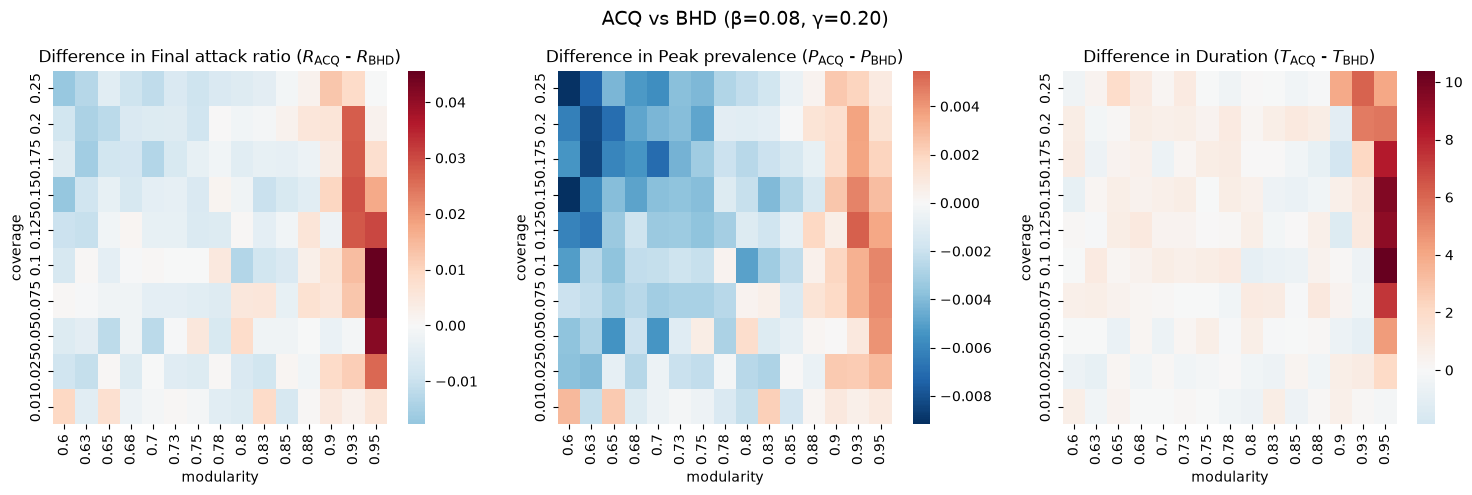

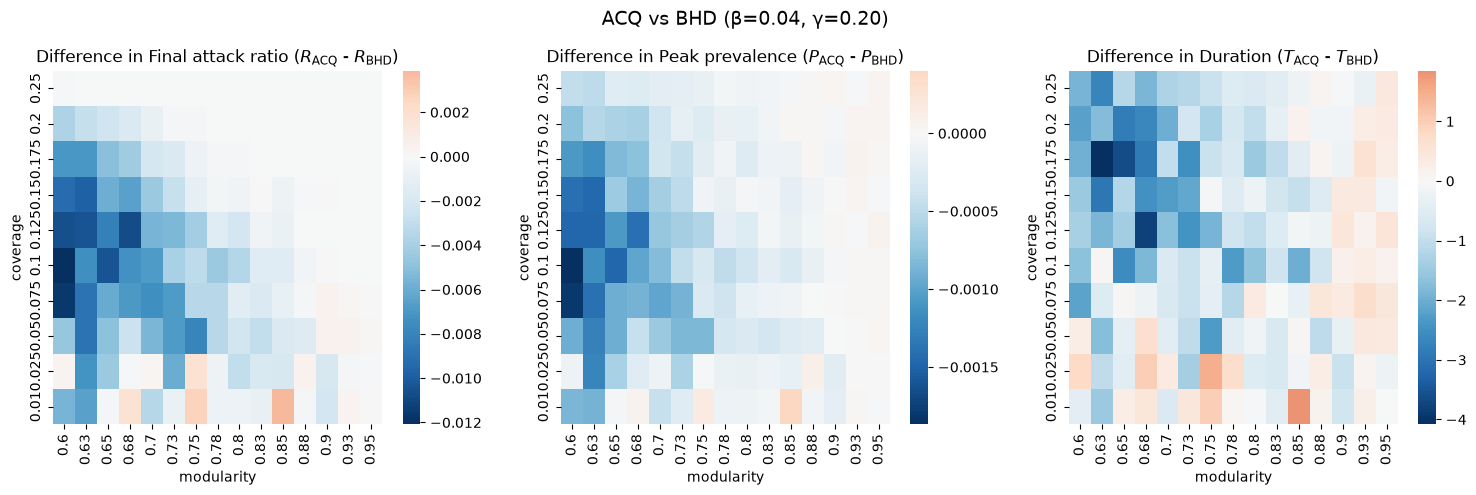

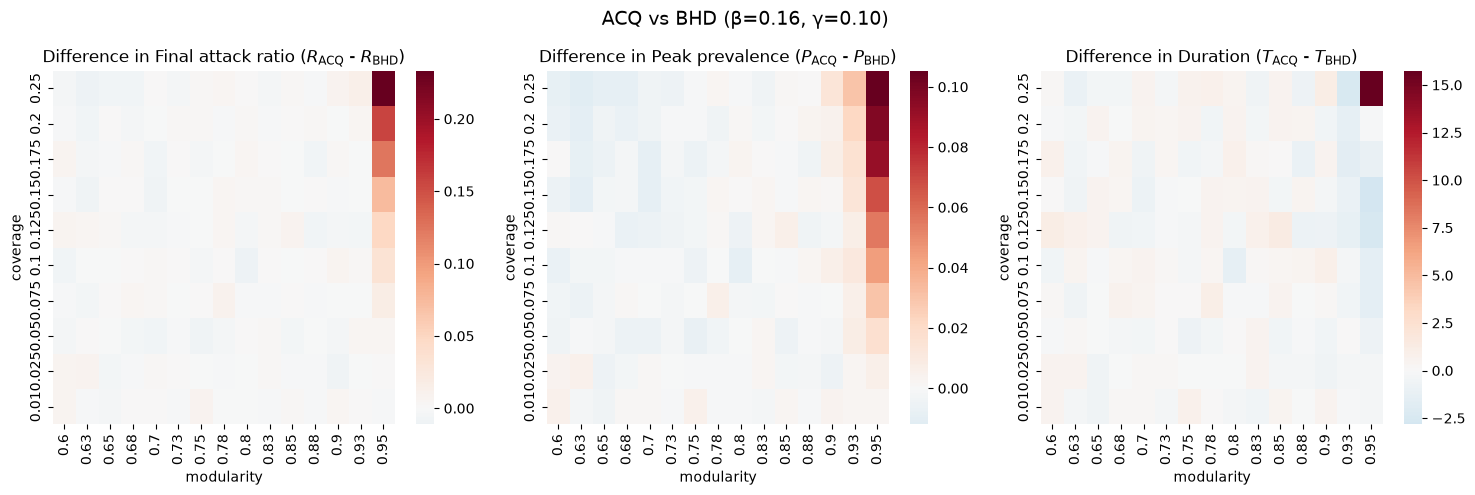

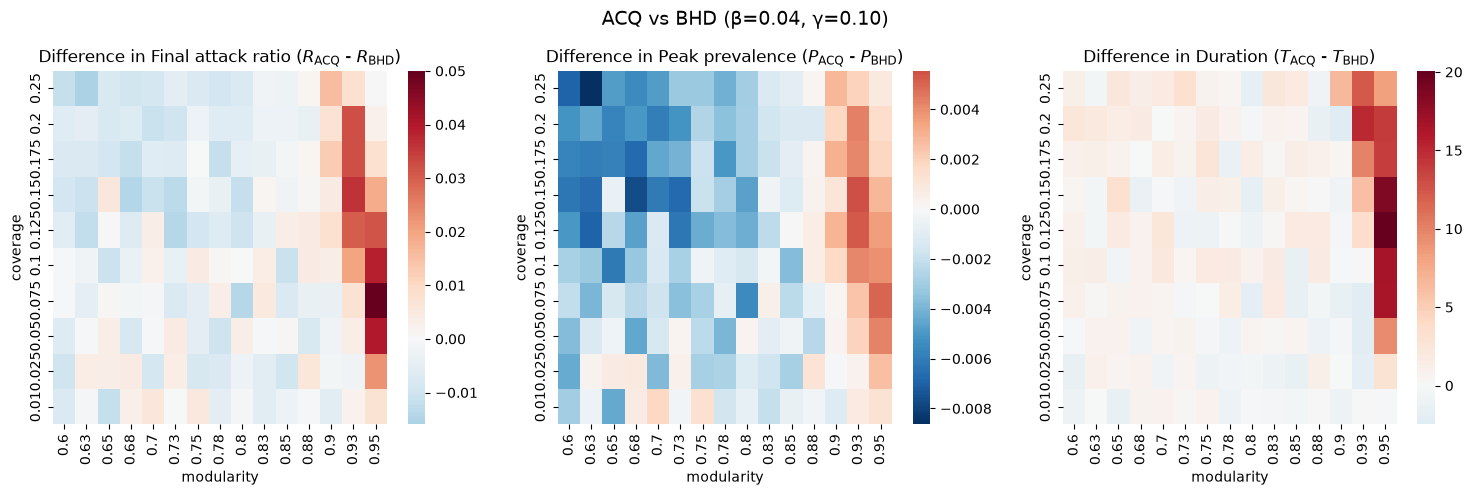

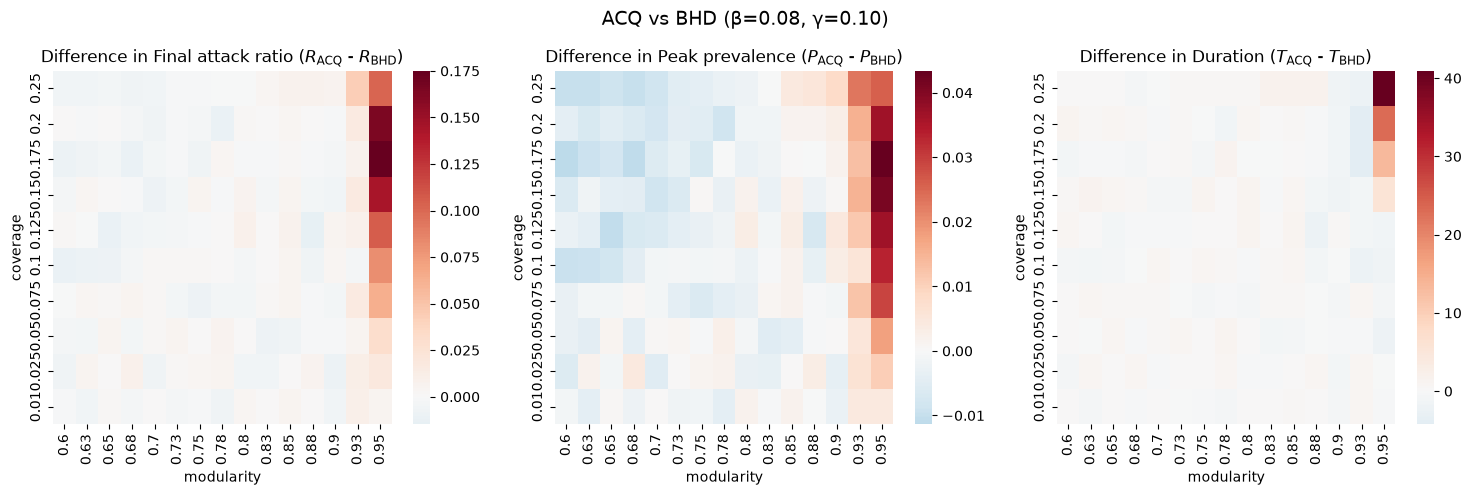

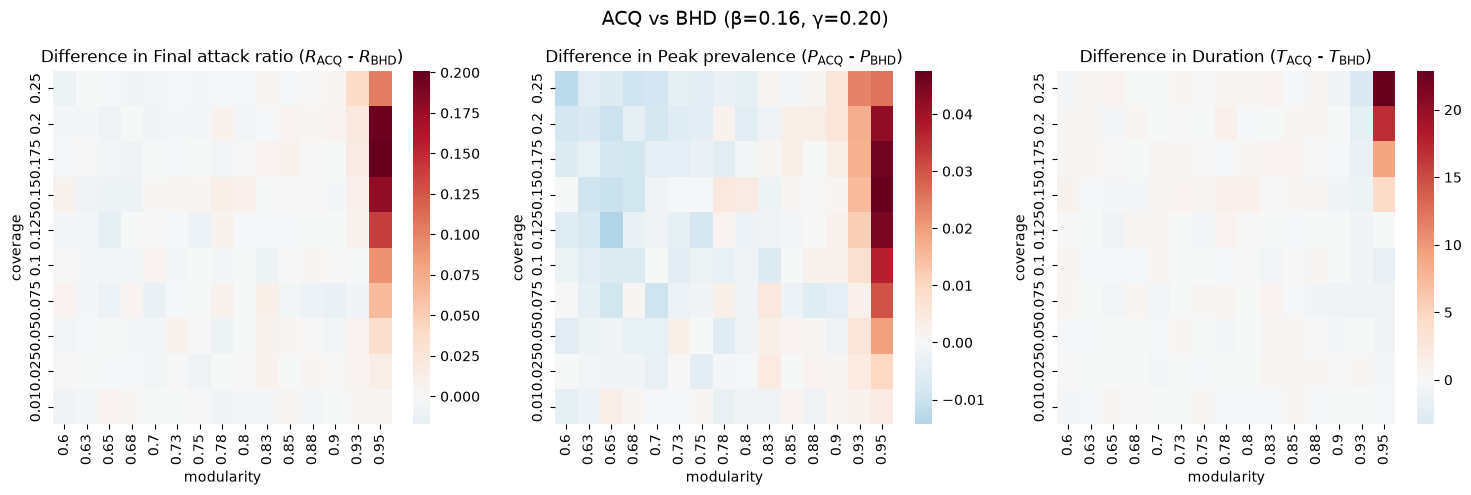

In [45]:
pairwise_comparison(df_avg, 'ACQ', 'BHD', METRIC_LABELS, METRIC_VAR_MAP)

Comparing algorithms: BNI-LI vs BNI-LI-local


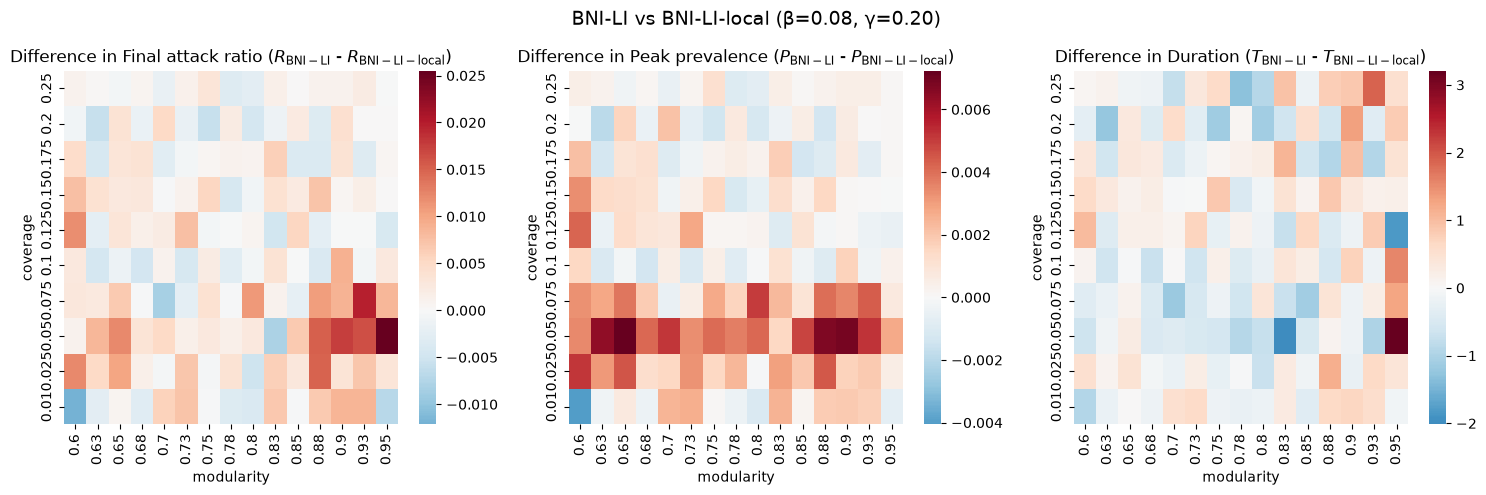

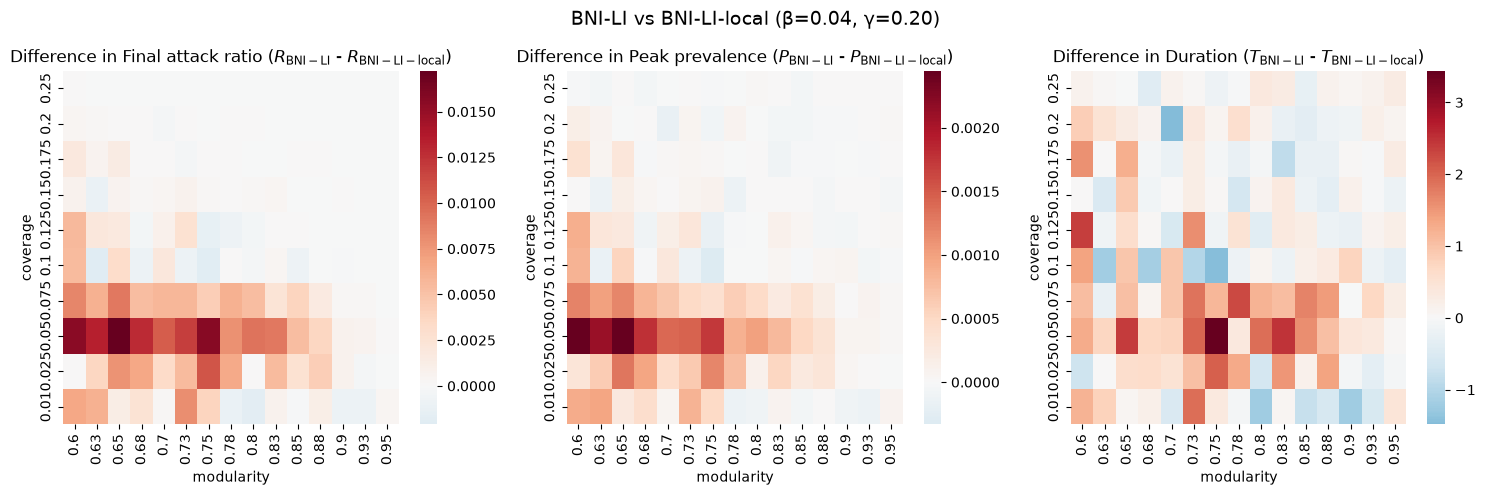

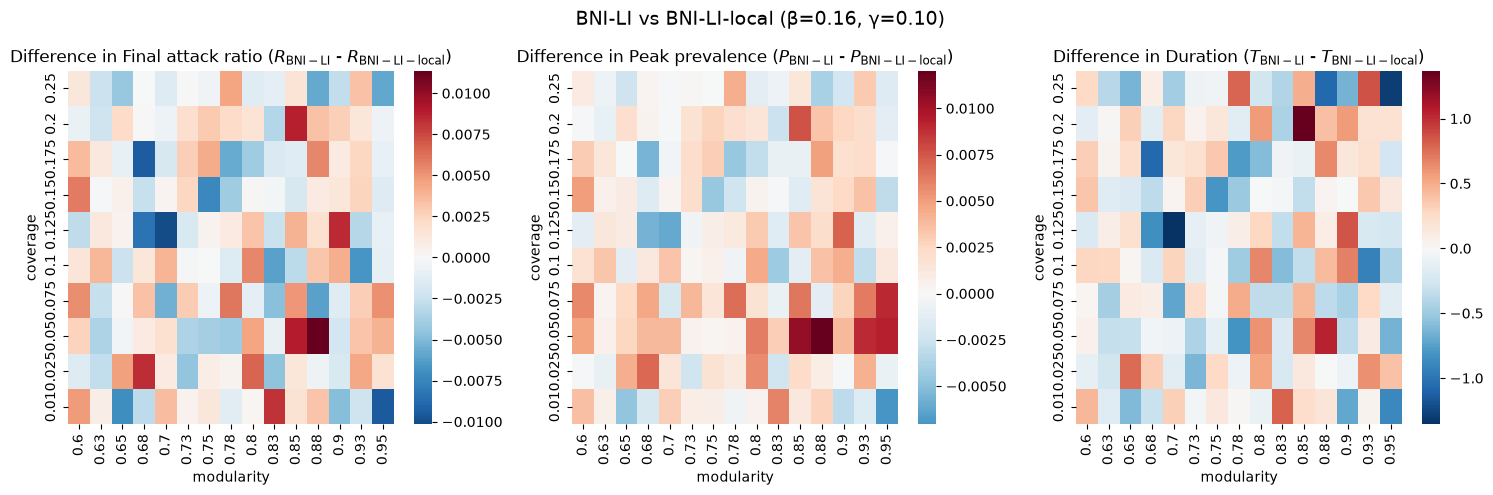

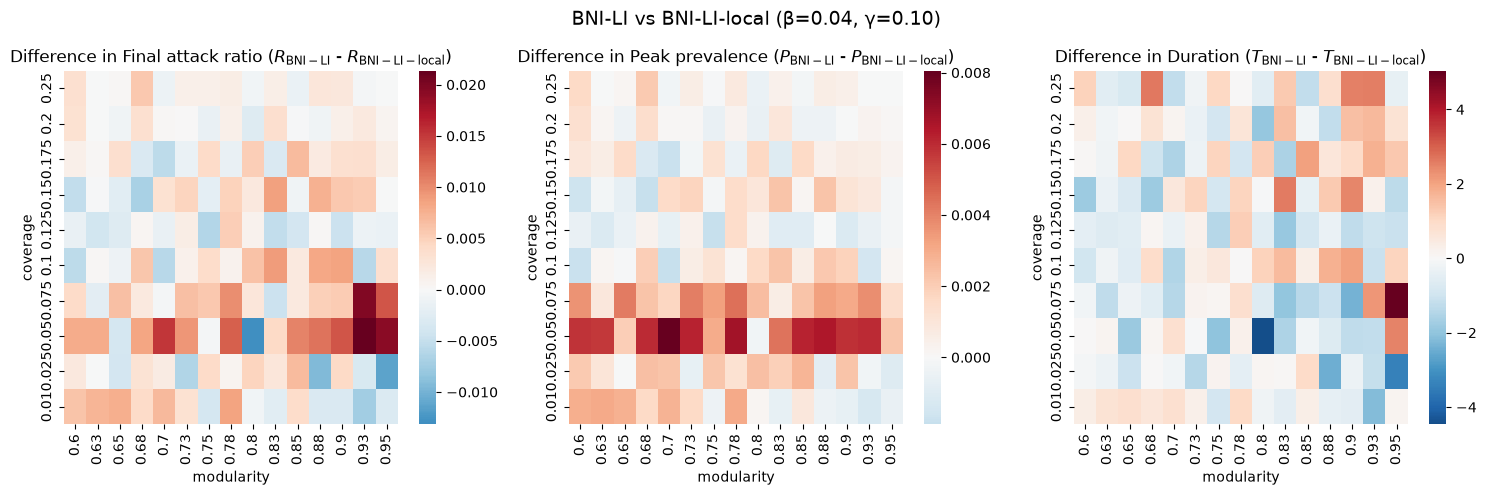

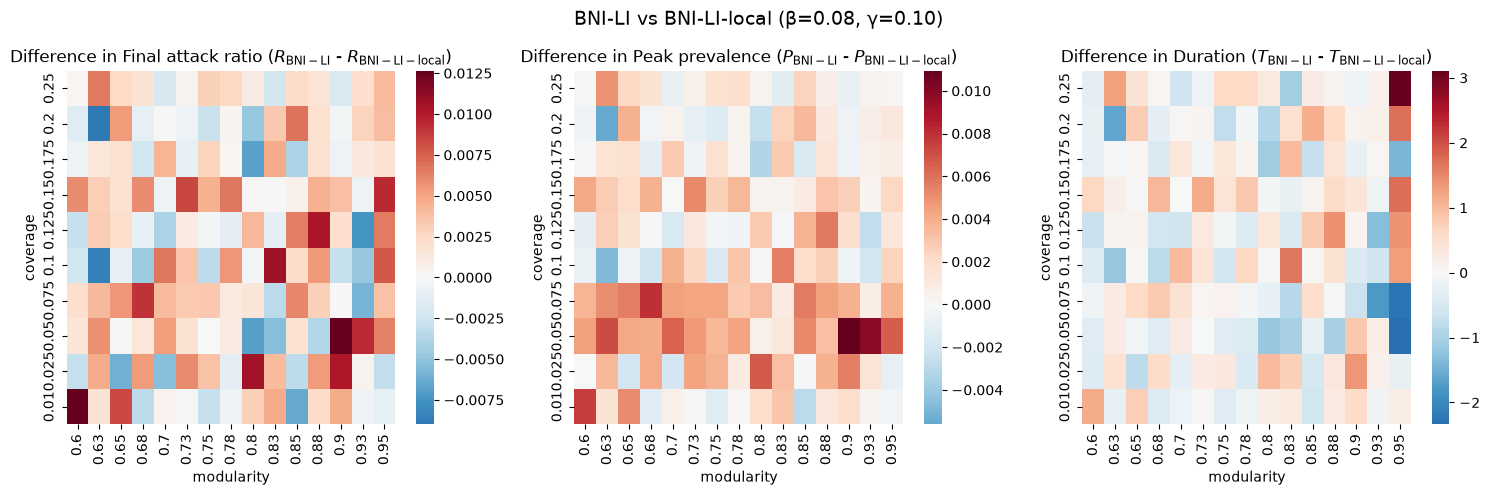

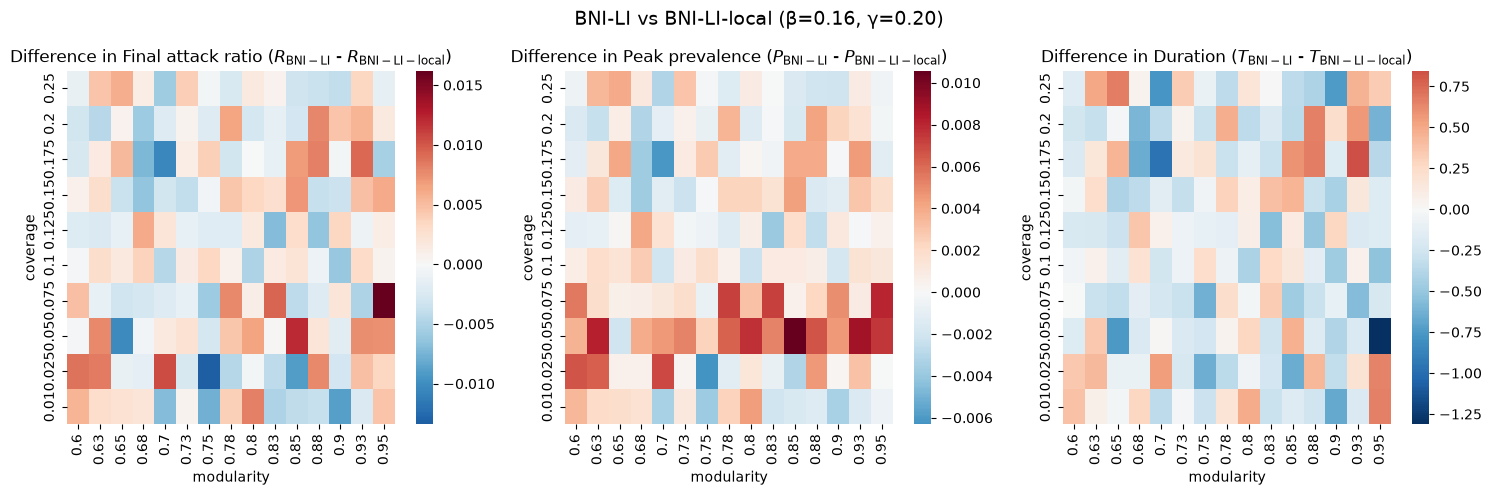

In [46]:
pairwise_comparison(df_avg, 'BNI-LI', 'BNI-LI-local', METRIC_LABELS, METRIC_VAR_MAP)

Comparing algorithms: ACQ vs BNI-LI


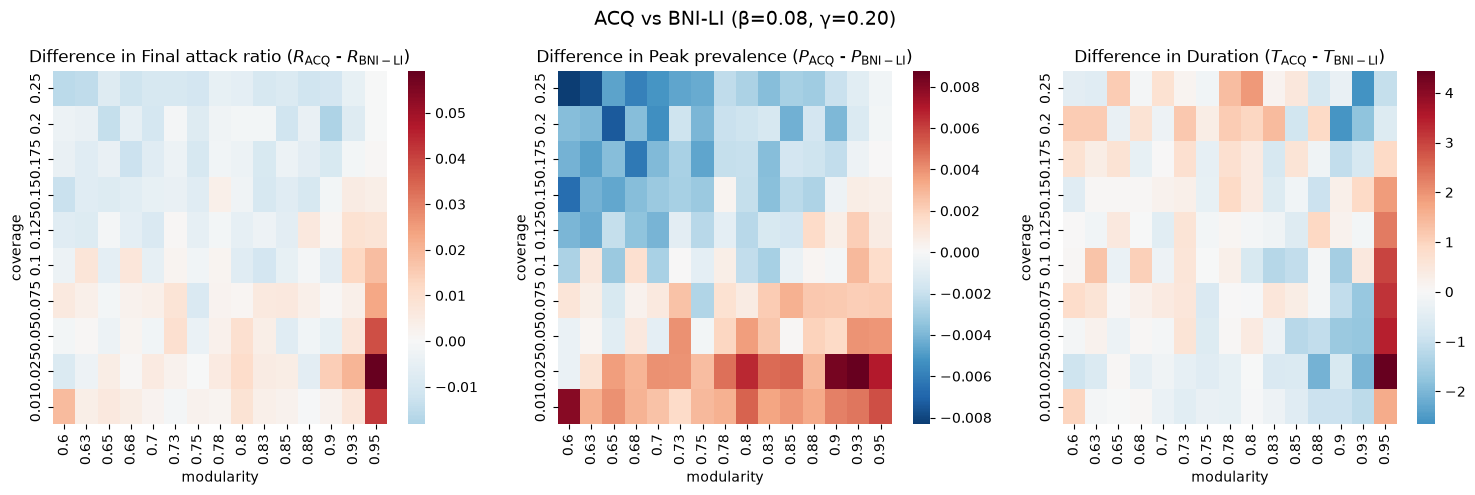

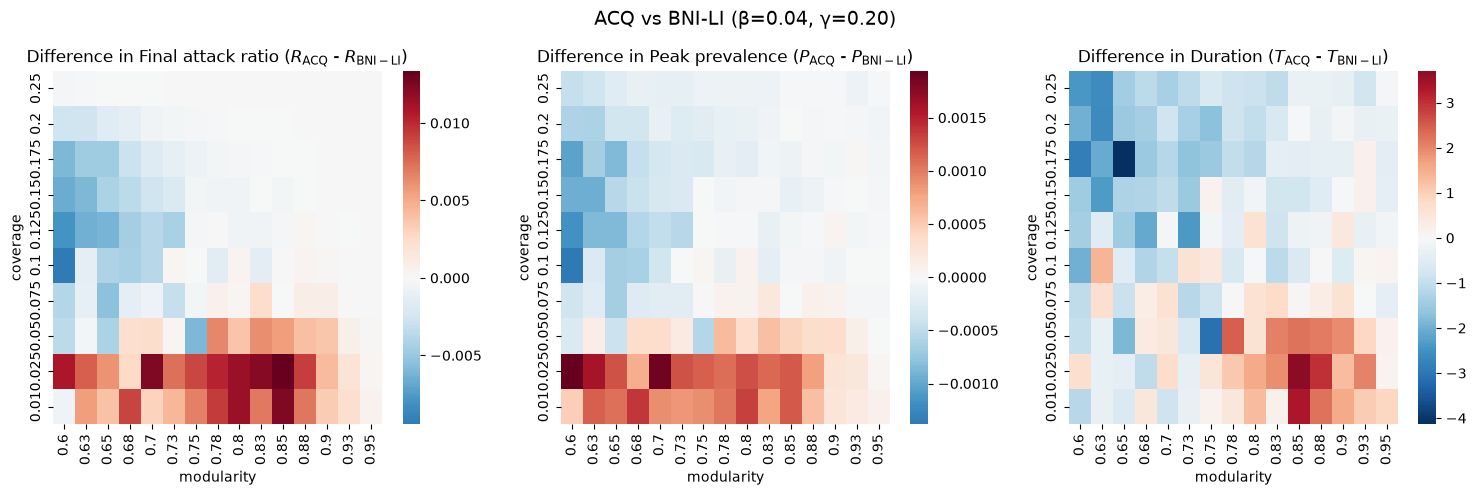

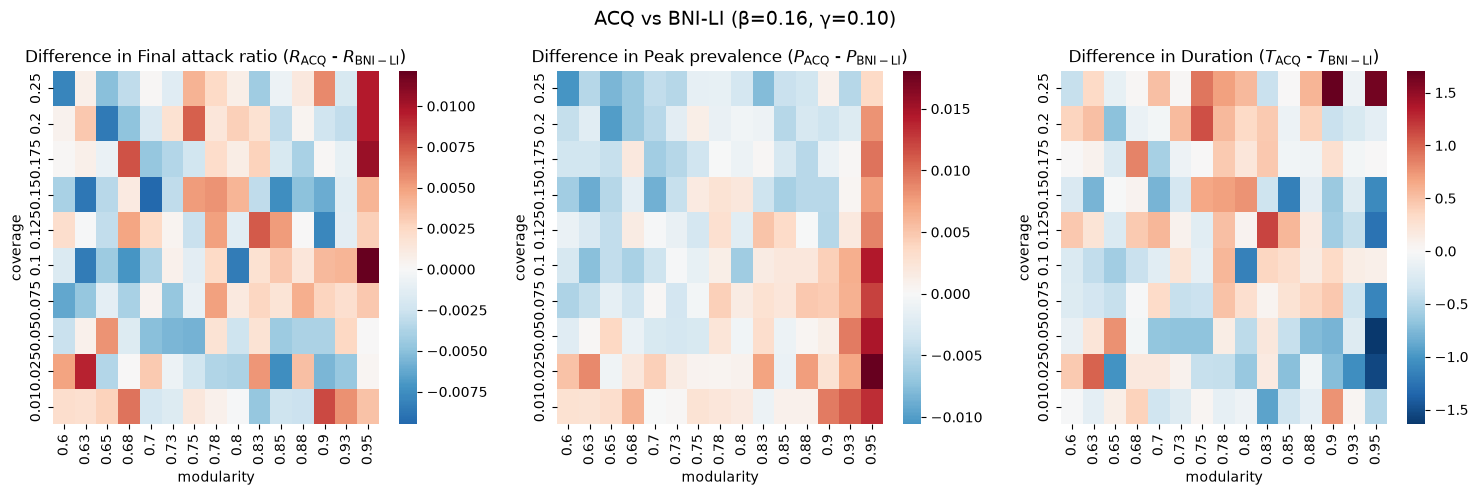

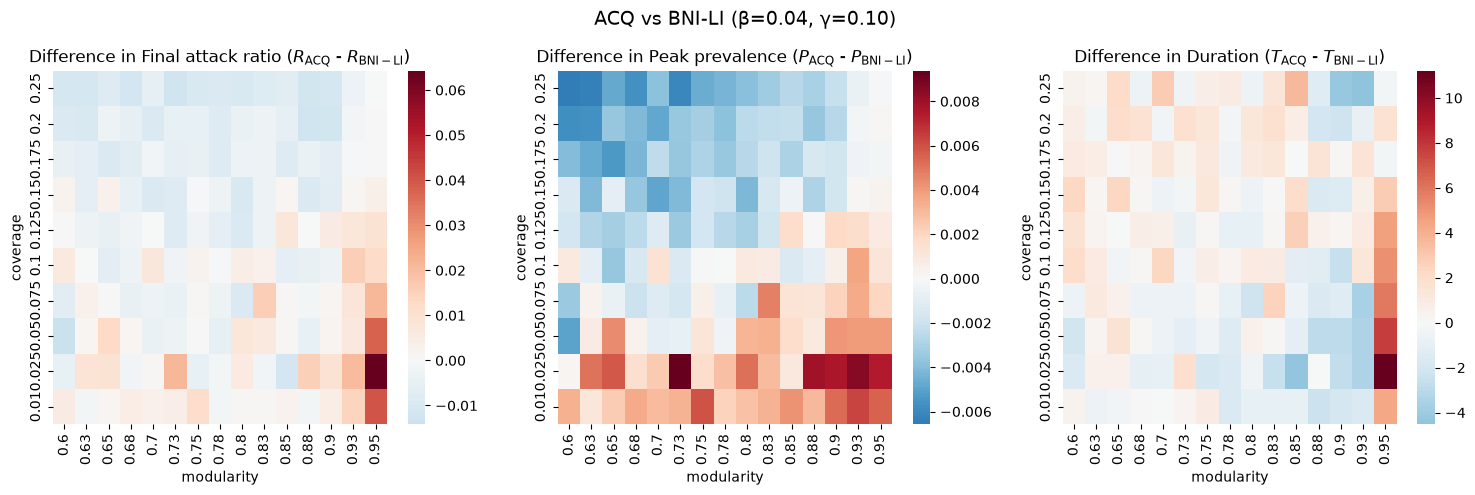

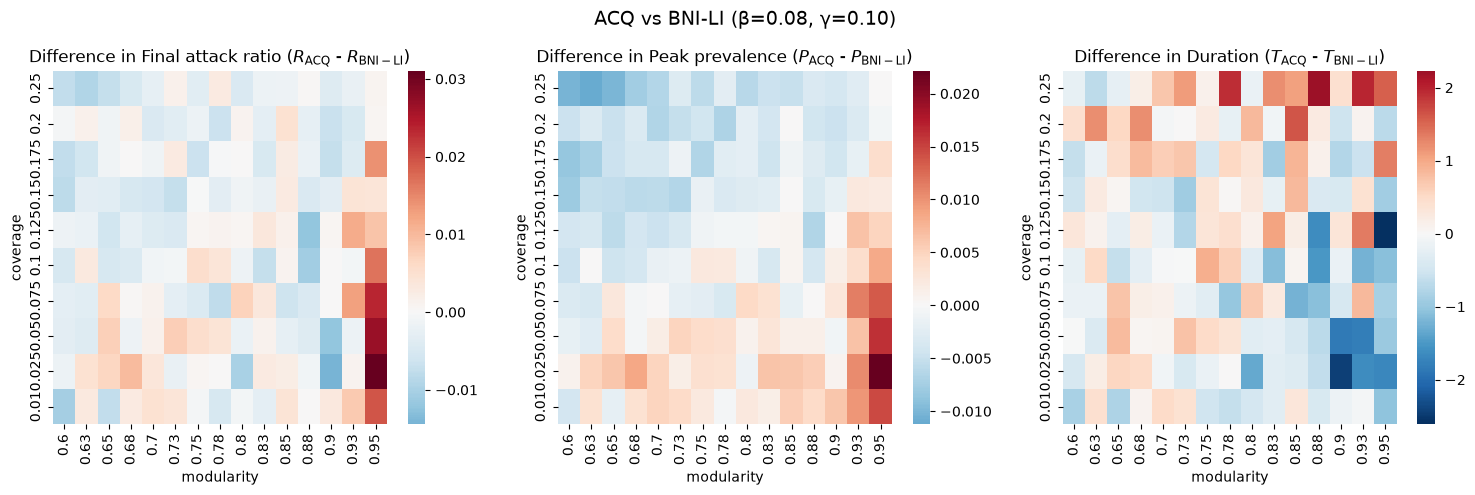

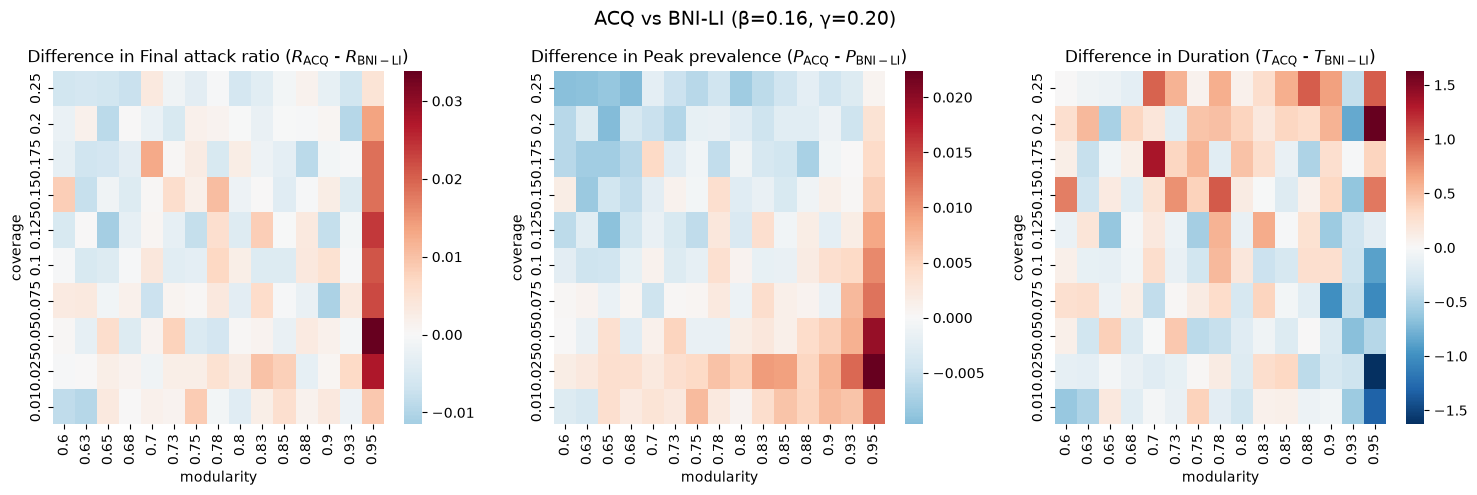

In [47]:
pairwise_comparison(df_avg, 'ACQ', 'BNI-LI', METRIC_LABELS, METRIC_VAR_MAP)

Comparing algorithms: ACQ vs BNI-LI-local


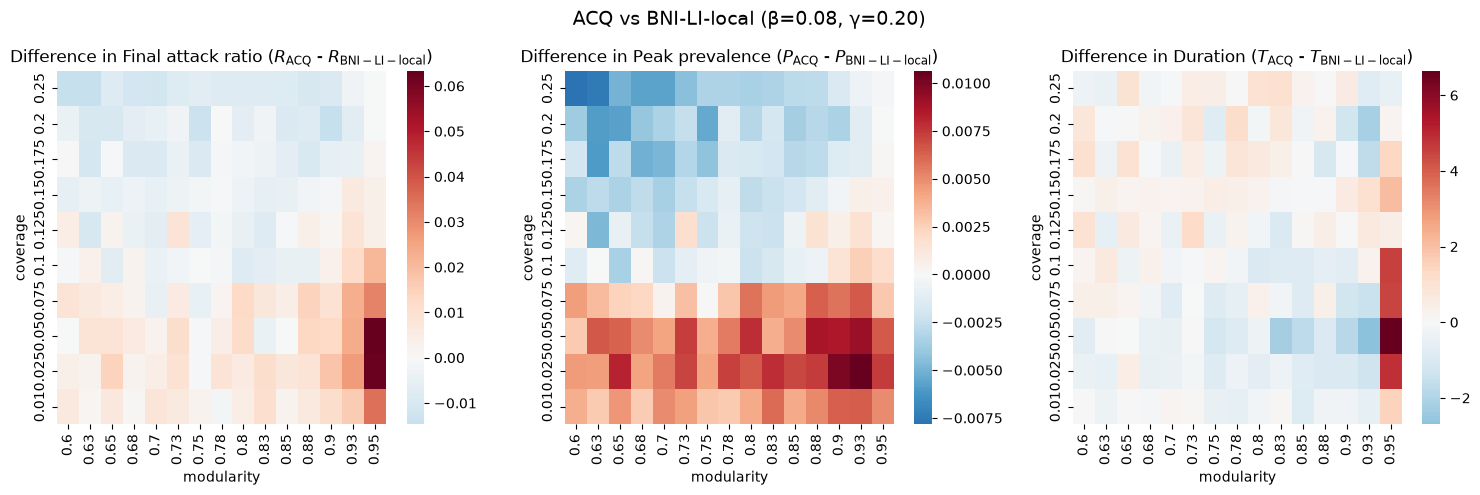

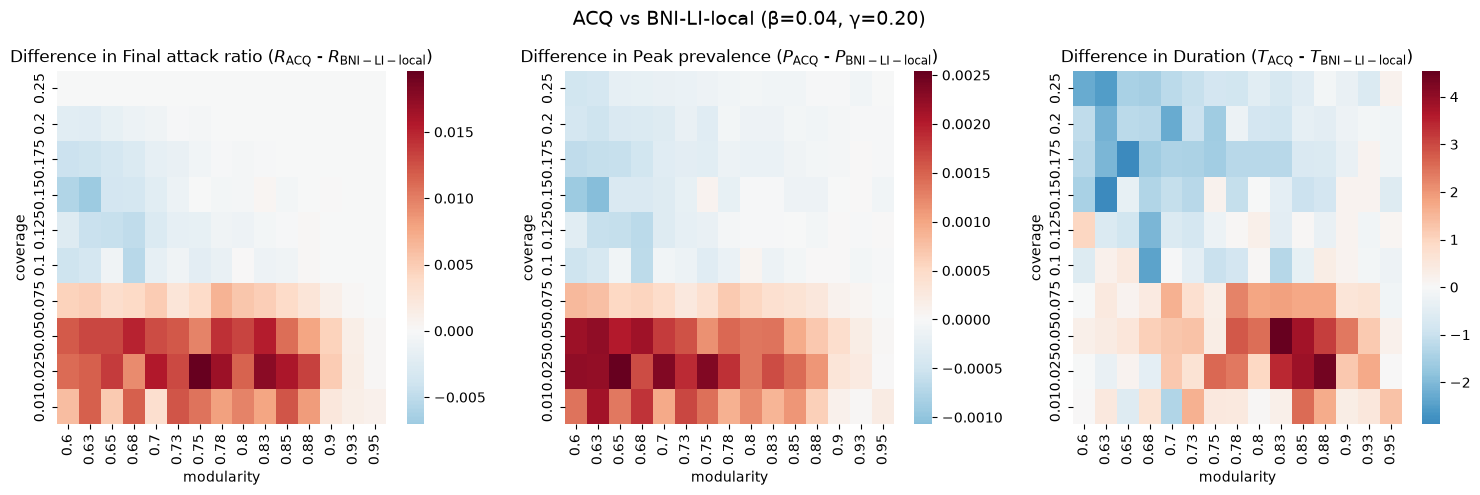

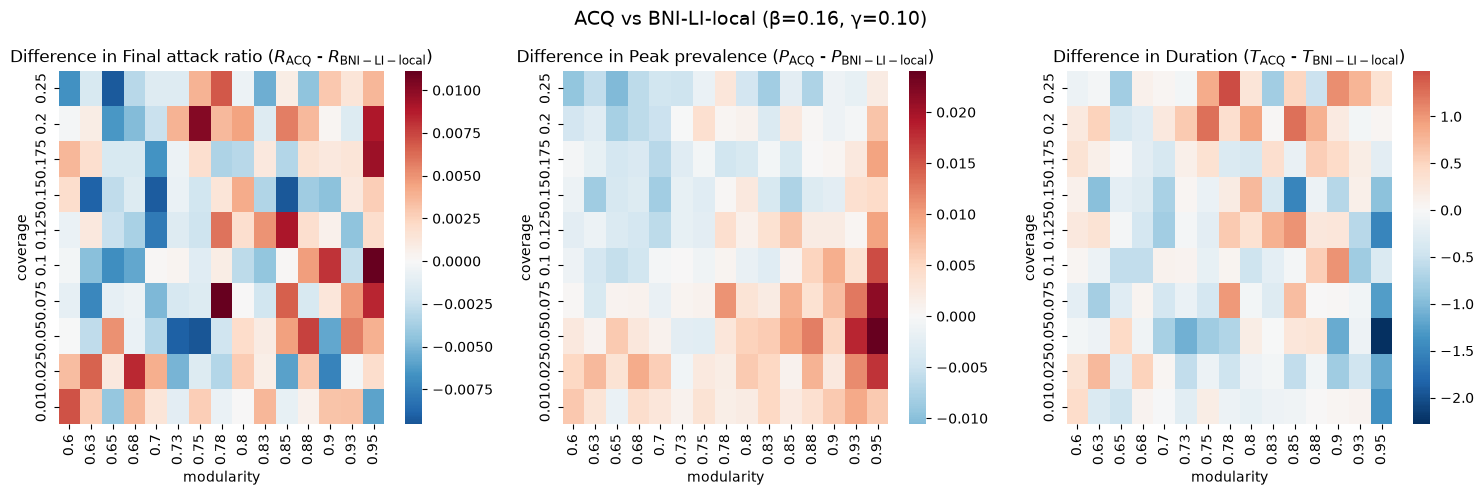

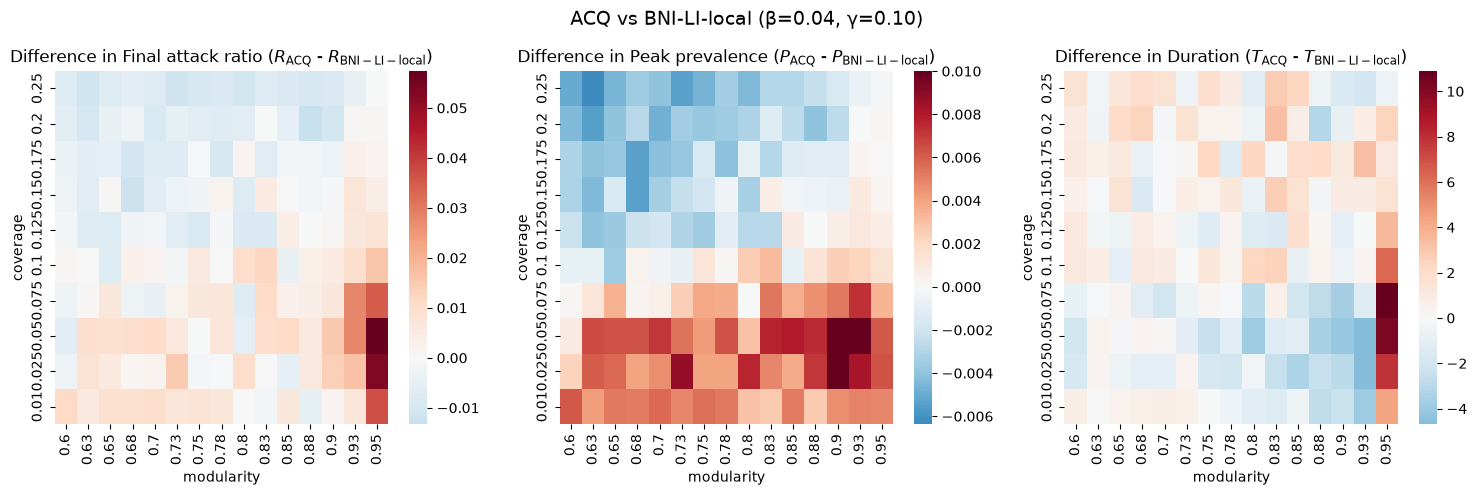

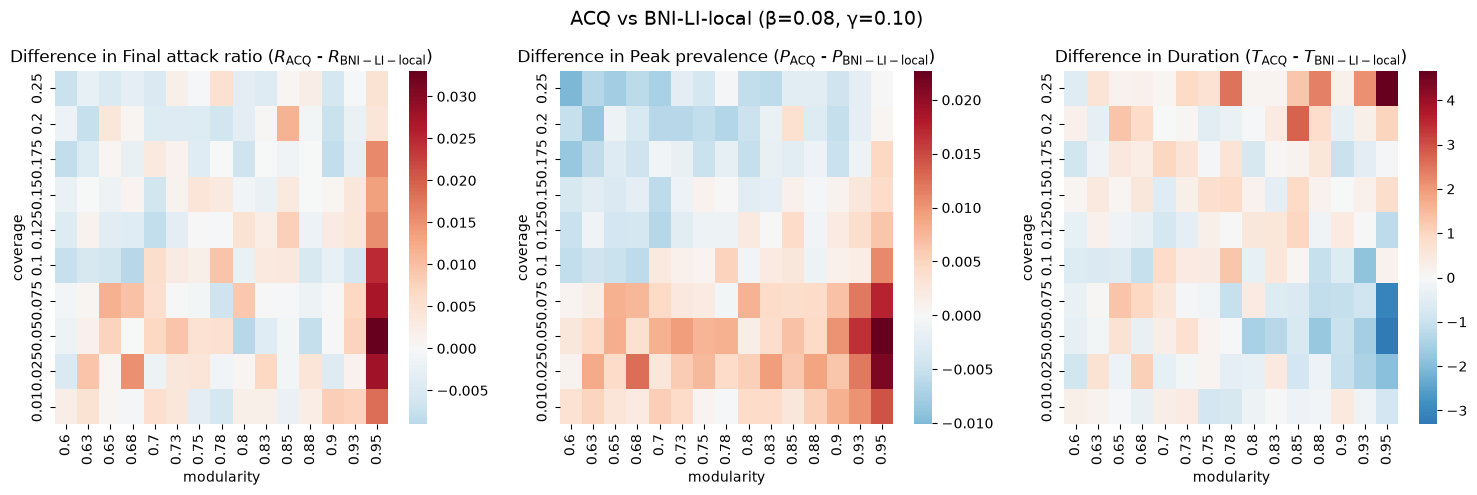

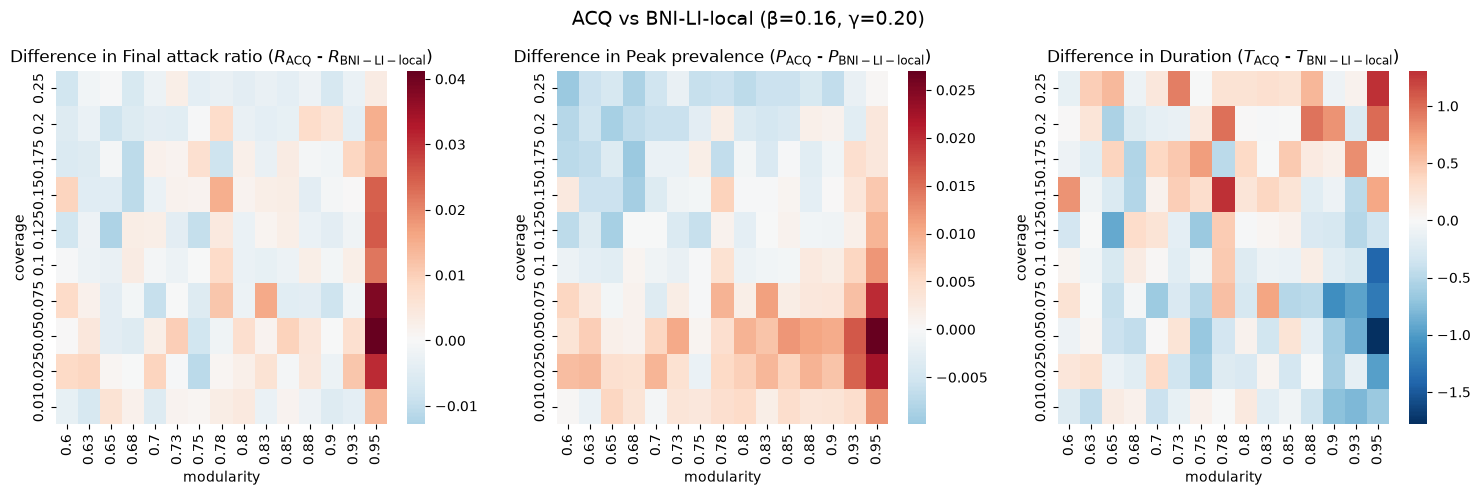

In [48]:
pairwise_comparison(df_avg, 'ACQ', 'BNI-LI-local', METRIC_LABELS, METRIC_VAR_MAP)